# CONFIGURATION

All configurations for pipeline to run can be altered below

**PREREQUISITES**:

- Data/Articles/Output Directories Exist

- Base Article datasets are stored in Data/Articles for optimal running

- A Saved sentiment_finetuned_xlmr model that is trained on full article data sentiment as opposed to mention-level sentiment
    - Trained using the smaller dataset `Articles2024_batch_labelled.csv` found in **Data/Articles**
- A Saved sentiment_finetuned_xlmr_mentions model that is trained on mention-level sentiment labels
    - Trained using the smaller dataset `Articles2024_mentions_sample_labelled.csv` found in **Data/Articles**


In [3]:
INPUT_CSV_PATH_2024 = "Data\Articles\Articles2024.csv"  # Path of the input 2024 CSV file containing the articles data
OUTPUT_CSV_PATH_2024 = "Data\Articles\Output\Articles2024_enriched.csv" # Path of the output 2024 CSV file to save the enriched articles data
OUTPUT_MENTIONS_CSV_PATH_2024 = "Data\Articles\Output\Articles2024_mentions.csv" # Path of the output 2024 CSV file to save the extracted mentions data

INPUT_CSV_PATH_2025 = "Data\Articles\Articles2025.csv"  # Path of the input 2025 CSV file containing the articles data 
OUTPUT_CSV_PATH_2025 = "Data\Articles\Output\Articles2025_enriched.csv" # Path of the output 2025 CSV file to save the enriched articles data
OUTPUT_MENTIONS_CSV_PATH_2025 = "Data\Articles\Output\Articles2025_mentions.csv" # Path of the output 2025 CSV file to save the extracted mentions data

MENTION_SENTIMENT_MODEL_PATH = "./sentiment_finetuned_xlmr_mentions" # Path of the fine-tuned sentiment analysis model for mentions
ARTICLE_SENTIMENT_MODEL_PATH = "./sentiment_finetuned_xlmr" # Path of the fine-tuned sentiment analysis model for articles

## IMPORTS

In [2]:
import os
import re
import json
import math
from typing import Dict, List, Tuple, Optional, Any, Iterable
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
import spacy
from spacy.language import Language
from spacy.tokens import Doc
import pycountry
import torch
from datasets import Dataset
from transformers import pipeline
import seaborn as sns
import ast

c:\Users\User\miniconda3\envs\FYPenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# NATIONALITY-AWARE NER + SENTIMENT ANALYSIS + FRAMING

## 1. Implementation of Gazetteer
Mapping values in text to a Country code (ISO3 format)

In [ ]:
# GAZETTEER (COUNTRIES + DEMONYMS + GROUP LABELS) -> CANONICAL CODE

# Normalizes a string so that different textual variations map to the same dictionary key
def _normalize_key(s: str) -> str:
    s = s.lower().strip()   # lowercase + remove leading/trailing whitespace
    s = re.sub(r"[\u2019\u2018’`]", "'", s) # normalize curly apostrophes to standard apostrophe
    s = re.sub(r"\s+", " ", s)  # collapse multiple spaces into single space
    s = re.sub(r"[^a-z0-9\s'\-]", "", s)    # remove punctuation except letters, numbers, space, apostrophe, hyphen
    return s


# Returns a mapping from surface forms (country names, demonyms, aliases, group labels)
# to a canonical code in ISO3 format (e.g., "USA", "GBR", "FRA").
def build_nationality_gazetteer() -> Dict[str, str]:
    gaz: Dict[str, str] = {}

    # Populate dictionairy using pycountry (structured country database)
    for c in pycountry.countries:
        iso3 = getattr(c, "alpha_3", None)
        if not iso3:
            continue
        names = {c.name}
        if hasattr(c, "official_name"):
            names.add(c.official_name)
        if hasattr(c, "common_name"):
            names.add(c.common_name)

        for n in names:
            gaz[_normalize_key(n)] = iso3

    # curated demonyms (adjectival nationality forms)
    # note: spaCy's NER often labels demonyms as NORP (nationalities/religious groups), so we want to ensure they are included in the gazetteer for mapping to ISO3 codes
    # This is used hand-in-hand with the Rule patterns defined using regex in the NER component.
    demonyms = {
        "maltese": "MLT",
        "gozitan": "MLT",
        "italian": "ITA",
        "french": "FRA",
        "german": "DEU",
        "spanish": "ESP",
        "british": "GBR",
        "english": "GBR",
        "irish": "IRL",
        "scottish": "GBR",
        "welsh": "GBR",
        "american": "USA",
        "russian": "RUS",
        "ukrainian": "UKR",
        "chinese": "CHN",
        "indian": "IND",
        "pakistani": "PAK",
        "bangladeshi": "BGD",
        "nigerian": "NGA",
        "libyan": "LBY",
        "tunisian": "TUN",
        "algerian": "DZA",
        "moroccan": "MAR",
        "egyptian": "EGY",
        "israeli": "ISR",
        "palestinian": "PSE",
        "syrian": "SYR",
        "lebanese": "LBN",
        "turkish": "TUR",
        "turk": "TUR",
        "greek": "GRC",
        "polish": "POL",
        "romanian": "ROU",
        "bulgarian": "BGR",
        "serbian": "SRB",
        "croatian": "HRV",
        "hungarian": "HUN",
        "swedish": "SWE",
        "norwegian": "NOR",
        "danish": "DNK",
        "finnish": "FIN",
        "dutch": "NLD",
        "albanian": "ALB",
        "belgian": "BEL",
        "portuguese": "PRT",
        "brazilian": "BRA",
        "argentinian": "ARG",
        "mexican": "MEX",
        "australian": "AUS",
        "new zealander": "NZL",
        "south african": "ZAF",
        "north korean": "PRK",
        "south korean": "KOR",
        "saudi arabian": "SAU",
        "costa rican": "CRI",
        "japanese": "JPN",
        "iranian": "IRN",
        "iraqi": "IRQ",
        "afghan": "AFG",
        "ghanaian": "GHA",
        "gambian": "GMB",
        "sudanese": "SDN",
        "somali": "SOM",
        "macedonian": "MKD",
        "ethiopian": "ETH",
        "eritrean": "ERI",
        "nepali": "NPL",
        "nepalese": "NPL",
        "sri lankan": "LKA",
        "colombian": "COL",
        "austrian": "AUT",
        "czech": "CZE",
        "slovak": "SVK",
        "slovenian": "SVN",
        "estonian": "EST",
        "latvian": "LVA",
        "lithuanian": "LTU",
        "icelandic": "ISL",
        "luxembourgish": "LUX",
        "monegasque": "MCO",
        "saudi": "SAU",
        "emirati": "ARE",
        "qatari": "QAT",
        "kuwaiti": "KWT",
        "yemeni": "YEM",
        "omani": "OMN",
        "bahraini": "BHR",
        "jordanian": "JOR",
        "saudi": "SAU",
        "emirati": "ARE",
        "qatari": "QAT",
        "kuwaiti": "KWT",
        "yemeni": "YEM",
        "omani": "OMN",
        "bahraini": "BHR",
        "jordanian": "JOR",
        "indonesian": "IDN",
        "malaysian": "MYS",
        "thai": "THA",
        "vietnamese": "VNM",
        "filipino": "PHL",
        "mongolian": "MNG",
        "canadian": "CAN",
        "peruvian": "PER",
        "chilean": "CHL",
        "venezuelan": "VEN",
        "ecuadorian": "ECU",
        "bolivian": "BOL",
        "cuban": "CUB",
        "belarusian": "BLR",
    }
    for k, v in demonyms.items():
        gaz[_normalize_key(k)] = v

    return gaz

## 2. Implementation of NER
Pattern rules and spaCy transformer

In [ ]:
# Loads a spaCy English transformer pipeline to extract entities (GPE/LOC/ORG/NORP/MISC) 
# and provide sentence boundaries for context extraction.
def load_spacy_ner(model_name: str = "en_core_web_trf") -> Language:
    nlp = spacy.load(model_name)

    # Ensure sentence boundaries exist (As we rely on sentence context later)
    if "parser" not in nlp.pipe_names and "senter" not in nlp.pipe_names:
        nlp.add_pipe("sentencizer") # simple rule-based sentence splitter

    return nlp

# Regex-based patterns to catch nationality mentions that NER may miss
RULE_PATTERNS = [
    # demonym + role noun (such as 'Italian national')
    re.compile(
        r"\b(?P<lemma>[A-Za-z][A-Za-z\-']+)\s+"
        r"(national|nationals|citizen|citizens|migrant|migrants|refugee|refugees|"
        r"detainee|detainees|asylum seeker|asylum seekers|immigrant|immigrants|"
        r"man|men|woman|women|person|people|worker|workers|student|students|crowd|individual|individuals|couple)\b",
        re.I
    ),
    # group noun + "from" + country span (such as "migrants from Libya")
    re.compile(
        r"\b(national|nationals|citizen|citizens|migrant|migrants|refugee|refugees|"
        r"detainee|detainees|asylum seeker|asylum seekers|immigrant|immigrants|"
        r"man|men|woman|women|person|people|worker|workers|student|students|individual|individuals)\s+"
        r"from\s+(?P<country>[A-Z][A-Za-z\-\s']{1,40}?)\b",
        re.I
    ),
]


# Splits raw text into paragraphs using the '\n' character as a separator. 
def split_paragraphs(text: str) -> List[str]:
    text = (text or "").strip()
    if not text:
        return []
    
    # Treat one-or-more blank lines as paragraph boundaries
    parts = re.split(r"\n\s*\n+", text)
    parts = [p.strip() for p in parts if p.strip()]
    return parts



# Best-effort paragraph lookup for a sentence
def find_paragraph_index(paragraphs: List[str], sentence: str) -> int:    
    sent_norm = sentence.strip()

    # Exact containment match
    for i, p in enumerate(paragraphs):
        if sent_norm and sent_norm in p:
            return i
        
    # if not found, approximate by token overlap
    sent_words = set(_normalize_key(sent_norm).split())
    best_i, best_score = -1, 0
    for i, p in enumerate(paragraphs):
        p_words = set(_normalize_key(p).split())
        score = len(sent_words & p_words)
        if score > best_score:
            best_i, best_score = i, score
    return best_i if best_i >= 0 else 0


# Matches a surface string to a canonical ISO3 code using the gazetteer
def match_gazetteer(surface: str, gaz: Dict[str, str]) -> Optional[str]:
    key = _normalize_key(surface)
    if key in gaz:
        return gaz[key]

    # handles possessives like "Italy's"
    key2 = re.sub(r"'s$", "", key)
    if key2 in gaz:
        return gaz[key2]

    # handles plural demonyms like "Italians"
    if key.endswith("s") and key[:-1] in gaz:
        return gaz[key[:-1]]

    return None


# Main extraction routine: combines NER and targeted regex rules   
def extract_nationality_mentions(
    nlp: Language,
    gaz: Dict[str, str],
    title: str,
    subtitle: str,
    content: str,
    top_image_caption: str = "",
) -> Dict[str, Any]:
    
    # Split the article into logical sections so we can later analyze framing by section
    sections = {
        "title": title or "",
        "subtitle": subtitle or "",
        "content": content or "",
        "top_image_caption": top_image_caption or "",
    }

    mentions: List[Dict[str, Any]] = [] # all mention records (may contain duplicates before dedup step)
    found_codes: set = set()    # unique set of ISO3 codes found

    # Process each section independently so mentions can be attributed to title/subtitle/content/top_image_caption
    for section_name, text in sections.items():
        if not text.strip():
            continue

        paragraphs = split_paragraphs(text)  # store paragraph blocks for later paragraph-level context
        doc = nlp(text)                      # run spaCy for tokenization, NER, and sentence segmentation

        # 1: NER-based extraction: iterate over spaCy entities, filter by label, then match to gazetteer
        for ent in doc.ents:
            if ent.label_ != "NORP":
                continue # ignore entity types not relevant to person-nationality mention detection

            code = match_gazetteer(ent.text, gaz)  # map to ISO3 code

            # Only accept if we can map to ISO3, else ignore to avoid noise
            if code:
                # Sentence context (for sentence-level sentiment)
                sent_text = ent.sent.text if ent.sent is not None else text

                # Paragraph context (for paragraph-level sentiment)
                p_idx = find_paragraph_index(paragraphs, sent_text) if paragraphs else 0
                paragraph = paragraphs[p_idx] if paragraphs else sent_text

                # Store a mention record with metadata for sentiment + topic + framing analysis later
                mentions.append({
                    "code": code,
                    "surface": ent.text,
                    "section": section_name,
                    "method": "spacy_ner+gazetteer",
                    "label": ent.label_,
                    "sentence": sent_text.strip(),
                    "paragraph": paragraph.strip(),
                    "char_start": int(ent.start_char),
                    "char_end": int(ent.end_char),
                })
                found_codes.add(code)
        
        # 2: Pattern-based rules by applying regex patterns to raw text
        for pat in RULE_PATTERNS:
            for m in pat.finditer(text):
                
                # Capture the candidate string from the appropriate regex group (country or lemma (demonym-like word))
                cand = m.groupdict().get("lemma") or m.groupdict().get("country") or ""
                cand = (cand or "").strip()

                # truncate country capture if text is long
                cand = re.split(r"[,\.;:\n]", cand)[0].strip()

                if not cand:
                    continue

                # Map candidate token/phrase to ISO3 using the same gazetteer
                code = match_gazetteer(cand, gaz)
                if not code:
                    continue

                # Identify the sentence containing this regex match using char offsets
                start = m.start()
                end = m.end()
                sent_text = None
                for s in doc.sents:
                    if s.start_char <= start < s.end_char:
                        sent_text = s.text
                        break
                if sent_text is None:
                    sent_text = text    # fallback if no sentence boundaries found

                # Map sentence to paragraph
                p_idx = find_paragraph_index(paragraphs, sent_text) if paragraphs else 0
                paragraph = paragraphs[p_idx] if paragraphs else sent_text

                # metadata for sentiment and framing analysis later
                mentions.append({
                    "code": code,
                    "surface": cand,    # extracted nationality/country phrase
                    "section": section_name,
                    "method": "pattern_rule",
                    "label": None,
                    "sentence": sent_text.strip(),
                    "paragraph": paragraph.strip(),
                    "char_start": int(start),
                    "char_end": int(end),
                })
                found_codes.add(code)

    # Remove duplicate mentions
    # Keep only one mention per (nationality code, sentence, section),
    # even if both spaCy NORP and pattern rules found it.
    # Prefer pattern_rule over spacy when both exist.
    method_priority = {
        "pattern_rule": 0,
        "spacy_ner+gazetteer": 1,
    }

    best_mentions = {}
    for mm in mentions:
        key = (
            mm["code"],
            _normalize_key(mm["sentence"]),
            mm["section"],
        )

        if key not in best_mentions:
            best_mentions[key] = mm
        else:
            current = best_mentions[key]
            current_prio = method_priority.get(current.get("method"), 99)
            new_prio = method_priority.get(mm.get("method"), 99)

            if new_prio < current_prio:
                best_mentions[key] = mm

    deduped = list(best_mentions.values())

    return {
        "nationalities": sorted(found_codes),
        "mentions": deduped,
    }


# SENTIMENT (sentence-level for mentions, paragraph-level, article-level)
def load_sentiment_pipeline(
    model_name: str = "./sentiment_finetuned_xlmr_mentions",   # the saved model folder (after training)
    device: Optional[int] = None,
):
    if device is None:
        device = 0 if torch.cuda.is_available() else -1

    return pipeline(
        "text-classification",
        model=model_name,
        tokenizer=model_name,
        device=device,
        truncation=True,
        max_length=512,
        return_all_scores=True,   # IMPORTANT
        top_k=None,              # return all labels/scores, not just top-k
    )


# Ensures HuggingFace pipeline's output is formatted into a consistent shape
# Shape is:  List[{"label": str, "score": float}, ...]
def _coerce_to_label_score_list(x) -> List[Dict[str, float]]:
    if x is None:
        return []

    # if output is already a list
    if isinstance(x, list):
        if len(x) == 0:
            return []
        if isinstance(x[0], dict) and "label" in x[0] and "score" in x[0]:
            return x
        
        if isinstance(x[0], list):
            
            inner = x[0]
            if inner and isinstance(inner[0], dict):
                return inner
        return []

    # if output is a dict
    if isinstance(x, dict):
        if "label" in x and "score" in x:
            return [x]
       
        if all(isinstance(v, (int, float)) for v in x.values()):
            return [{"label": str(k), "score": float(v)} for k, v in x.items()]
        return []

    # Else return empty if it is any other type
    return []


# Convert output for an instance of text into a dict of {negative, neutral, positive}.
def _sentiment_scores_to_standard(one_text_output) -> Dict[str, float]:

    items = _coerce_to_label_score_list(one_text_output) # Ensure formatting of shape

    # Build label-score map with normalized lowercase keys
    scores = {}
    for d in items:
        lab = str(d.get("label", "")).lower()
        sc = float(d.get("score", 0.0))
        scores[lab] = sc

    # If the model outputs explicit sentiment labels, use them directly
    if any(k in scores for k in ["negative", "neutral", "positive"]):
        return {
            "negative": scores.get("negative", 0.0),
            "neutral": scores.get("neutral", 0.0),
            "positive": scores.get("positive", 0.0),
        }

    # if not, label_0/1/2 fallback as this is common practice
    if any(k.startswith("label_") for k in scores):
        return {
            "negative": scores.get("label_0", 0.0),
            "neutral": scores.get("label_1", 0.0),
            "positive": scores.get("label_2", 0.0),
        }

    # treat the strongest label as the sentiment, default to neutral as the best sentiment as the last resort.
    if not scores:
        return {"negative": 0.0, "neutral": 1.0, "positive": 0.0}

    best_lab = max(scores, key=scores.get)
    best_sc = scores[best_lab]
    neg = best_sc if "neg" in best_lab else 0.0
    neu = best_sc if "neu" in best_lab else 0.0
    pos = best_sc if "pos" in best_lab else 0.0
    # if none matched, treat as neutral
    if neg == neu == pos == 0.0:
        neu = best_sc
    return {"negative": neg, "neutral": neu, "positive": pos}


# Runs sentiment prediction on a list of texts using the HF pipeline
def predict_sentiment(sent_pipeline, texts: List[str], batch_size: int = 16) -> List[Dict[str, Any]]:
    results: List[Dict[str, Any]] = []

    for i in range(0, len(texts), batch_size):
        batch = [t if (t and str(t).strip()) else "" for t in texts[i:i+batch_size]]

        outs = sent_pipeline(batch)

        # HF sometimes returns a non-list output for single items
        if not isinstance(outs, list):
            outs = [outs]

        for out in outs:
            probs = _sentiment_scores_to_standard(out)  # {"negative":..., "neutral":..., "positive":...}
            label = max(probs, key=probs.get) if probs else "neutral"  # <-- ARGMAX (no thresholds)
            results.append({"label": label, "probs": probs})

    return results

'\ndef predict_sentiment(sent_pipe, texts: List[str], neutral_margin: float = 0.10) -> List[Dict]:\n\n    #Returns list of:\n    #{\n    #    "label": "positive|neutral|negative",\n    #    "probs": {"positive": p, "neutral": n, "negative": g}\n    #}\n\n    if not texts:\n        return []\n\n    outputs = sent_pipe(texts, batch_size=16, truncation=True)\n\n    preds = []\n    for out in outputs:\n        probs = _sentiment_scores_to_standard(out)\n\n        # sort probabilities from highest to lowest\n        sorted_items = sorted(probs.items(), key=lambda x: x[1], reverse=True)\n        top_label, top_score = sorted_items[0]\n        second_label, second_score = sorted_items[1]\n\n        # all zero or near-zero case\n        if sum(probs.values()) == 0:\n            label = "neutral"\n        # tie / near-tie case\n        elif (top_score - second_score) < neutral_margin:\n            label = "neutral"\n        else:\n            label = top_label\n\n        preds.append({\n       

## 3. Implementation of Framing

In [ ]:
TOKEN_RE = re.compile(r"[a-z0-9]+(?:['\-][a-z0-9]+)*")

def _tokenize_norm_text(s: str) -> List[str]:
    s = _normalize_key(s)
    return TOKEN_RE.findall(s)

# Precompute normalized token n-grams for each frame
def _build_lexicon_ngrams(frame_lexicons: Dict[str, List[str]]) -> Dict[str, Dict[int, set]]:
    out: Dict[str, Dict[int, set]] = {}
    for frame, phrases in frame_lexicons.items():
        by_n: Dict[int, set] = {}
        for p in phrases:
            toks = _tokenize_norm_text(p)
            if not toks:
                continue
            n = len(toks)
            by_n.setdefault(n, set()).add(tuple(toks))
        out[frame] = by_n
    return out


""" 
Framing lexicons: curated lists of keywords/phrases indicative of different frames.
These are used for a simple keyword-based framing analysis to identify which frames are present in the context

| Frame        | Meaning                |
| ------------ | ---------------------- |
| humanitarian | protection / rescue    |
| security     | terrorism / safety     |
| crime        | criminal activity      |
| burden       | pressure on services   |
| economic     | labour / wages / taxes |
| integration  | social inclusion       |

"""
FRAME_LEXICONS: Dict[str, List[str]] = {

    "crime_frame": [
        "arrested", "charged", "indicted", "convicted",
        "trial", "sentenced", "pleaded guilty",
        "murder", "homicide", "manslaughter",
        "rape", "sexual assault",
        "robbery", "armed robbery", "theft", "burglary",
        "assault", "violent assault",
        "drug trafficking", "drug smuggling", "drug offences",
        "human trafficking", "trafficking ring",
        "fraud", "money laundering",
        "bribery", "corruption",
        "kidnapping", "abduction",
        "gang violence", "criminal network",
        "prison sentence", "jail sentence",
        "court proceedings", "police investigation",
        "suspected of", "accused of", "wanted by police"
    ],

    "humanitarian_frame": [
        "rescued at sea", "search and rescue", "rescue operation", "boat rescue",
        "migrants rescued", "saved at sea", "saved from drowning",
        "humanitarian aid", "humanitarian assistance", "humanitarian mission",
        "aid workers", "emergency relief", "medical assistance", "medical care",
        "temporary shelter", "safe shelter", "safe passage",
        "human rights", "rights protection", "rights groups",
        "asylum seeker", "asylum seekers", "seeking protection",
        "international protection", "refugee status", "granted asylum",
        "displaced persons", "internally displaced", "evacuated civilians",
        "vulnerable people", "vulnerable migrants", "women and children",
        "people in need", "humanitarian crisis", "drowned at sea",
        "shipwreck survivors", "survivors brought ashore", "rescue vessel",
        "asylum application", "asylum claim", "protection claim",
        "refugee camp", "reception centre", "open centre",
        "detained migrants", "migrant detention",
        "rescued migrants", "rescued people", "people rescued",
        "human dignity", "basic rights", "legal protection",
        "support services", "social support", "emergency support",
        "vulnerable families", "children in need", "families in need",
        "humanitarian concern", "humanitarian response", "aid delivery"
    ],

    "burden_frame": [
        "burden", "burden on taxpayers", "burden on public services",
        "strain on resources", "pressure on services", "pressure on housing",
        "pressure on infrastructure", "pressure on schools", "pressure on hospitals",
        "overstretched services", "capacity reached", "at full capacity",
        "overcrowded facilities", "overcrowded reception centres",
        "housing shortage", "shortage of housing", "lack of accommodation",
        "public spending increase", "rising public spending",
        "welfare dependency", "unsustainable levels",
        "migration surge", "mass influx", "influx of migrants",
        "cost to taxpayers", "rising costs", "resource constraints",
        "system under pressure", "services under pressure",
        "pressure on the system", "strain on the system", "stretched resources",
        "limited resources", "scarce resources", "lack of resources",
        "pressure on welfare", "pressure on benefits",
        "queues for housing", "competition for housing",
        "overcrowded shelters", "full reception centres",
        "capacity problems", "limited capacity", "insufficient capacity",
        "rising demand", "increased demand for services",
        "public cost", "financial burden", "cost pressure"
    ],

    "security_frame": [
        "security", "border security", "border control", "border patrol",
        "security operation", "security forces deployed",
        "national security threat", "public safety threat", "security risk",
        "counterterrorism operation", "terrorist threat", "terror threat",
        "radicalisation", "violent extremism", "extremist group",
        "militant group", "armed group",
        "detained at border", "detention centre",
        "deportation order", "deported", "deportation",
        "illegal entry", "irregular entry", "unauthorised entry",
        "smuggling network", "trafficking network", "border surveillance",
        "coast guard patrol", "law enforcement operation",
        "public safety", "safety concerns", "security concerns",
        "border management", "migration control", "immigration control",
        "enforcement action", "policing operation",
        "surveillance operation", "security response",
        "entry ban", "removal order", "return order",
        "detained migrants", "border crossing", "crossed the border",
        "smuggling route", "trafficking route"
    ],

    "economic_frame": [
        "economy", "economic impact", "economic contribution",
        "contribution to the economy", "boost to the economy",
        "labour market", "labor market", "job market",
        "job competition", "competition for jobs",
        "migrant workers", "foreign workers", "seasonal workers",
        "labour shortage", "labor shortage", "worker shortage",
        "fill labour shortages", "fill labor shortages",
        "workforce participation", "employment opportunities",
        "skills shortage", "tax contribution", "growth momentum",
        "tax revenue", "public finances", "social contributions",
        "supporting growth", "economic growth", "business activity",
        "work permits", "employment rate", "low paid work",
        "employment", "jobs", "job opportunities", "workers",
        "labour force", "labor force", "labour needs", "labor needs",
        "staff shortages", "recruitment difficulties",
        "contribute to growth", "support the economy",
        "support economic growth", "economic benefits",
        "tax base", "income tax", "pay taxes",
        "business needs", "employers need workers",
        "work visa", "working conditions", "earning wages",
        "wage levels", "cost of labour", "economic activity"
    ],

    "integration_frame": [
        "integration", "integrating", "social integration",
        "community integration", "integration programme", "integration program",
        "integration policy", "integration support", "integration efforts",
        "integration initiatives", "language training", "language classes",
        "learning maltese", "learning english",
        "cultural integration", "social inclusion", "inclusive society",
        "equal opportunities", "equal treatment",
        "anti discrimination", "racial discrimination", "ethnic discrimination",
        "discrimination claims", "community cohesion", "inclusion programmes",
        "school integration", "access to education", "access to work",
        "participation in society", "settling into the community",
        "intercultural dialogue", "integration measures",
        "inclusion", "social inclusion", "community support",
        "belonging in the community", "community participation",
        "language support", "school enrolment", "school enrollment",
        "access to services", "access to healthcare",
        "equal access", "equal participation",
        "settlement support", "settlement services",
        "welcoming communities", "living together", "social cohesion",
        "intercultural understanding", "civic participation",
        "part of society", "integrated into society"
    ],
}

# Single-word cues that need support from another hit
WEAK_UNIGRAMS = {
    "security_frame": {
        "security", "threat", "deportation", "detained", "surveillance"
    },
    "burden_frame": {
        "burden", "strain", "pressure", "capacity", "shortage", "overcrowded"
    },
    "economic_frame": {
        "economy", "employment", "workforce", "wages", "tax", "growth"
    },
    "integration_frame": {
        "integration", "inclusion", "cohesion", "discrimination"
    },
    "humanitarian_frame": {
        "aid", "rights", "shelter", "protection", "rescue",
        "asylum", "refugee", "medical", "vulnerable", "support"
    },
}

# Keyword backoff so rare frames do not stay at zero too often
FRAME_KEYWORDS: Dict[str, List[str]] = {

    "crime_frame": [
        "arrest", "charg", "convict", "sentenc", "murder", "homicid",
        "rape", "robber", "theft", "burgl", "assault", "fraud",
        "launder", "briber", "corrupt", "kidnap", "abduct",
        "gang", "traffick", "criminal", "police"
    ],

    "humanitarian_frame": [
        "rescu", "aid", "humanitarian", "asylum", "refugee", "protect",
        "right", "shelter", "relief", "medical", "displac",
        "vulnerab", "surviv", "drown", "evacuat", "support",
        "dignit", "camp", "reception"
    ],

    "burden_frame": [
        "burden", "strain", "pressur", "overstretch", "capacity",
        "overcrowd", "shortage", "housing", "taxpayer", "welfare",
        "service", "unsustain", "influx", "surge", "resource",
        "cost", "demand", "accommodat", "full"
    ],

    "security_frame": [
        "security", "border", "deport", "detain", "terror", "radical",
        "extrem", "patrol", "police", "militar", "armed", "threat",
        "risk", "surveil", "smuggl", "safety", "control",
        "enforc", "remov", "return"
    ],

    "economic_frame": [
        "econom", "labour", "labor", "job", "work", "worker", "employ",
        "tax", "revenue", "growth", "finance", "business", "skill",
        "shortage", "permit", "wage", "salary", "employer",
        "recruit", "contribut"
    ],

    "integration_frame": [
        "integrat", "inclus", "community", "language", "school",
        "educat", "discrimin", "cohes", "participat", "equal",
        "cultur", "settl", "intercultur", "access", "belong",
        "welcom", "society"
    ],
}

FRAME_LEXICONS_NGRAMS = _build_lexicon_ngrams(FRAME_LEXICONS)

# Get framing flags for a text based on lexicon matches
def compute_frame_flags(text: str) -> Dict[str, int]:
    tokens = _tokenize_norm_text(text)
    flags: Dict[str, int] = {}

    if not tokens:
        return {frame: 0 for frame in FRAME_LEXICONS.keys()}

    L = len(tokens)

    for frame, by_n in FRAME_LEXICONS_NGRAMS.items():
        if not by_n:
            flags[frame] = 0
            continue

        weak_unigrams = WEAK_UNIGRAMS.get(frame, set())

        strong_hit = False
        weak_hits = 0
        kw_hits = 0

        for n, lex_ngrams in by_n.items():
            if n > L:
                continue

            for i in range(0, L - n + 1):
                ng = tuple(tokens[i:i+n])
                if ng in lex_ngrams:
                    if n >= 2:
                        strong_hit = True
                        break
                    else:
                        if ng[0] in weak_unigrams:
                            weak_hits += 1
                        else:
                            strong_hit = True
                            break
            if strong_hit:
                break

        kw_list = FRAME_KEYWORDS.get(frame, [])
        if kw_list:
            for t in tokens:
                for kw in kw_list:
                    if t == kw or t.startswith(kw):
                        kw_hits += 1
                        break

        flags[frame] = int(
            strong_hit
            or (weak_hits >= 2)
            or ((weak_hits >= 1) and (kw_hits >= 2))
        )

    return flags


def _empty_frame_metrics(prefix: str = "") -> Dict[str, float]:
    out = {}
    for fr in FRAME_LEXICONS.keys():
        out[f"{prefix}{fr}"] = 0
        out[f"{prefix}{fr}_hits"] = 0.0
        out[f"{prefix}{fr}_unique"] = 0.0
        out[f"{prefix}{fr}_density"] = 0.0
    return out

# Aggregate mention-level framing to article-level
def _aggregate_mention_frame_metrics(
    mentions: List[Dict[str, Any]],
    prefix: str = ""
) -> Dict[str, float]:
    """
    For each frame:
      binary flag = whether any mention triggered it
      hits/unique/density = mean across mentions
    """
    if not mentions:
        return _empty_frame_metrics(prefix=prefix)

    out = {}
    for fr in FRAME_LEXICONS.keys():
        out[f"{prefix}{fr}"] = int(any(int(m.get(f"{prefix}{fr}", 0)) == 1 for m in mentions))
        out[f"{prefix}{fr}_hits"] = float(np.mean([float(m.get(f"{prefix}{fr}_hits", 0.0)) for m in mentions]))
        out[f"{prefix}{fr}_unique"] = float(np.mean([float(m.get(f"{prefix}{fr}_unique", 0.0)) for m in mentions]))
        out[f"{prefix}{fr}_density"] = float(np.mean([float(m.get(f"{prefix}{fr}_density", 0.0)) for m in mentions]))
    return out

# Compute intensity metrics for each frame based on n-gram matches and keyword hits.
def compute_frame_intensity(text: str) -> Dict[str, float]:
    
    """
    Intensity metrics with:
      - weighted n-gram phrase matches (longer phrases means higher weight)
      - keyword backoff hits (FRAME_KEYWORDS) to reduce zero-frames

    Returns intensity metrics per frame:
      - <frame>_hits: total number of matched n-grams (can be >1)
      - <frame>_unique: number of unique lexicon phrases matched
      - <frame>_density: hits per 100 tokens (length-normalized)
    """
    
    tokens = _tokenize_norm_text(text)
    out: Dict[str, float] = {}

    if not tokens:
        for frame in FRAME_LEXICONS.keys():
            out[f"{frame}_hits"] = 0.0
            out[f"{frame}_unique"] = 0.0
            out[f"{frame}_density"] = 0.0
        return out

    L = len(tokens)

    for frame, by_n in FRAME_LEXICONS_NGRAMS.items():
        weighted_hits = 0.0
        matched_ngrams = set()

        # phrase n-gram matche
        for n, lex_ngrams in by_n.items():
            if n > L:
                continue
            w = float(n)  # weight: unigram=1, bigram=2, trigram=3, ...
            for i in range(0, L - n + 1):
                gram = tuple(tokens[i:i+n])
                if gram in lex_ngrams:
                    weighted_hits += w
                    matched_ngrams.add(gram)

        # Count keyword hits
        kw_hits = 0
        kw_list = FRAME_KEYWORDS.get(frame, [])
        if kw_list:
            # substring matching via token prefix
            for t in tokens:
                for kw in kw_list:
                    if t == kw or t.startswith(kw):
                        kw_hits += 1
                        break

            # Gives keywords a smaller weight than phrases
            weighted_hits += 0.5 * float(kw_hits)

        unique = len(matched_ngrams)
        density = (weighted_hits / L) * 100.0  # per 100 tokens

        out[f"{frame}_hits"] = float(weighted_hits)
        out[f"{frame}_unique"] = float(unique)
        out[f"{frame}_density"] = float(density)

    return out

def add_framing_with_intensity_to_mentions(
    all_mentions: List[Dict[str, Any]],
    use_text_field: str = "sentence",
    out_prefix: str = "",
) -> List[Dict[str, Any]]:
    """
    Adds:
      - binary flags: <prefix><frame>
      - intensity:    <prefix><frame>_hits / _unique / _density
    based on the text in mention[use_text_field].
    """
    for m in all_mentions:
        text = (m.get(use_text_field) or "")

        # binary flags
        flags = compute_frame_flags(text)
        # intensity metrics
        intensity = compute_frame_intensity(text)

        # write into mention with prefix
        for k, v in flags.items():
            m[f"{out_prefix}{k}"] = int(v)

        for k, v in intensity.items():
            m[f"{out_prefix}{k}"] = float(v)

    return all_mentions


# Sentiment helper
def _safe_probs(m: Dict[str, Any], field: str = "sentiment_sentence") -> Dict[str, float]:
    probs = (m.get(field) or {}).get("probs") or {}
    return {
        "negative": float(probs.get("negative", 0.0)),
        "neutral": float(probs.get("neutral", 0.0)),
        "positive": float(probs.get("positive", 0.0)),
    }

# Enrich mentions with framing flags (sentence/paragraph)
def add_framing_to_mentions(
    all_mentions: List[Dict[str, Any]],
    use_text_field: str = "sentence",
    out_prefix: str = "",   # "" => crime_frame; "article_" => article_crime_frame etc
) -> List[Dict[str, Any]]:
    """
    Adds framing flags to each mention based on the chosen text field:
      use_text_field in {"sentence", "paragraph", ...}
    Flags are added as:
      f"{out_prefix}{frame_name}"
    """
    for m in all_mentions:
        text = m.get(use_text_field, "") or ""
        flags = compute_frame_flags(text)
        for k, v in flags.items():
            m[f"{out_prefix}{k}"] = int(v)
    return all_mentions


# Article-level framing
def add_article_framing_to_mentions(
    all_mentions: List[Dict[str, Any]],
    articles_df: pd.DataFrame,
    text_cols: Tuple[str, ...] = ("title", "subtitle", "content"),
) -> Dict[str, Any]:
    """
    Computes framing flags on full article text and attaches them to each mention by article_id.
    Outputs:
      - mentions enriched with *_article flags
      - articles_with_frames df (article_id + frame flags)
    """
    tmp = articles_df.copy()
    if "article_id" not in tmp.columns:
        raise ValueError("articles_df must contain 'article_id'")

    for c in text_cols:
        if c not in tmp.columns:
            tmp[c] = ""

    tmp["article_text"] = (
        tmp[list(text_cols)]
        .fillna("")
        .astype(str)
        .agg("\n".join, axis=1)
        .str.strip()
    )

    # Compute per-article frame flags
    frame_rows = tmp["article_text"].apply(compute_frame_flags).tolist()
    frame_df = pd.DataFrame(frame_rows)
    tmp = pd.concat([tmp.reset_index(drop=True), frame_df.reset_index(drop=True)], axis=1)

    # Lookup article_id -> frame flags
    lookup = tmp.set_index("article_id")[list(FRAME_LEXICONS.keys())].to_dict(orient="index")

    # Attach to each mention
    for m in all_mentions:
        aid = m.get("article_id")
        if aid in lookup:
            info = lookup[aid]
            for frame in FRAME_LEXICONS.keys():
                m[f"{frame}_article"] = int(info.get(frame, 0))
        else:
            for frame in FRAME_LEXICONS.keys():
                m[f"{frame}_article"] = 0

    return {
        "mentions": all_mentions,
        "articles_with_frames": tmp[["article_id", *FRAME_LEXICONS.keys()]].copy(),
    }

"""
    Aggregates framing rates per nationality: mean of binary frame flags over mentions.
    Also includes mean sentiment probs (sentence-level)
"""
def summarize_by_nationality_framing(all_mentions: List[Dict[str, Any]]) -> pd.DataFrame:
    
    if not all_mentions:
        return pd.DataFrame()

    rows = []
    for m in all_mentions:
        probs = _safe_probs(m, "sentiment_sentence")
        row = {
            "code": m.get("code"),
            "sent_neg_mean": probs["negative"],
            "sent_neu_mean": probs["neutral"],
            "sent_pos_mean": probs["positive"],
        }
        for frame in FRAME_LEXICONS.keys():
            row[frame] = int(m.get(frame, 0))
        rows.append(row)

    d = pd.DataFrame(rows)

    counts = d.groupby("code").size().reset_index(name="n_mentions")

    sent_means = (
        d.groupby("code")[["sent_neg_mean", "sent_neu_mean", "sent_pos_mean"]]
        .mean()
        .reset_index()
    )

    frame_means = (
        d.groupby("code")[list(FRAME_LEXICONS.keys())]
        .mean()
        .reset_index()
    )

    out = counts.merge(sent_means, on="code", how="left").merge(frame_means, on="code", how="left")
    out = out.sort_values(["n_mentions"], ascending=False).reset_index(drop=True)
    return out

# Aggregates article-level frames per nationality
def summarize_by_nationality_article_framing(all_mentions: List[Dict[str, Any]]) -> pd.DataFrame:
    if not all_mentions:
        return pd.DataFrame()

    rows = []
    for m in all_mentions:
        row = {"code": m.get("code")}
        for frame in FRAME_LEXICONS.keys():
            row[f"{frame}_article"] = int(m.get(f"{frame}_article", 0))
        rows.append(row)

    d = pd.DataFrame(rows)

    counts = d.groupby("code").size().reset_index(name="n_mentions")

    frame_means = (
        d.groupby("code")[[f"{k}_article" for k in FRAME_LEXICONS.keys()]]
        .mean()
        .reset_index()
    )

    out = counts.merge(frame_means, on="code", how="left")
    out = out.sort_values(["n_mentions"], ascending=False).reset_index(drop=True)
    return out

## 4. Implementation of Pipeline Run

In [ ]:
"""
Function that:
    1) Loads the article CSV
    2) Extracts nationality mentions (NER + dictionary + rules)
    3) Computes sentiment at multiple granularities (sentence/paragraph/article)
    4) Writes:
        - an enriched CSV (article-level aggregates)
        - a CSV mentions file (mention-level details per nationality extraction instance)

Returns:
    out_df: the enriched dataframe
    mentions_df: the mention-level dataframe
    output_csv_path: where article-level enriched CSV was saved
    output_mentions_csv_path: where mention-level CSV was saved
"""
def run_pipeline_on_csv(
    input_csv_path: str,
    output_csv_path: str,
    output_mentions_csv_path: str,
    spacy_model: str = "en_core_web_trf",
    mention_sentiment_model: str = "cardiffnlp/twitter-xlm-roberta-base-sentiment", # base model 
    article_sentiment_model: str = "cardiffnlp/twitter-xlm-roberta-base-sentiment"  # base model
):
    df = pd.read_csv(input_csv_path)

    for col in ["article_id", "title", "subtitle", "content", "top_image_caption"]:
        if col not in df.columns:
            raise ValueError(f"Missing required column: {col}. Found columns: {list(df.columns)}")

    gaz = build_nationality_gazetteer()
    print(f"Loaded nationality gazetteer with {len(gaz)} entries.")

    nlp = load_spacy_ner(spacy_model)
    print(f"Loaded spaCy model: {spacy_model}")

    sent_pipe = load_sentiment_pipeline(mention_sentiment_model)
    article_pipe = load_sentiment_pipeline(article_sentiment_model)
    print(f"Loaded sentiment model for sentence-level analysis: {mention_sentiment_model}")
    print(f"Loaded sentiment model for article-level analysis: {article_sentiment_model}")

    enriched_rows = []
    mention_rows = []

    for _, row in df.iterrows():
        article_id = row["article_id"]
        title = str(row.get("title") or "")
        subtitle = str(row.get("subtitle") or "")
        content = str(row.get("content") or "")
        top_image_caption = str(row.get("top_image_caption") or "")

        ner_out = extract_nationality_mentions(nlp, gaz, title, subtitle, content, top_image_caption)
        mentions = ner_out["mentions"]
        nationality_codes = ner_out["nationalities"]

        sentence_texts = [m["sentence"] for m in mentions]
        paragraph_texts = [m["paragraph"] for m in mentions]
        full_text = "\n".join([t for t in [title, subtitle, content, top_image_caption] if t.strip()])

        sent_sentiments = predict_sentiment(sent_pipe, sentence_texts) if sentence_texts else [] # Using sentence-level sentiment model for sentence contexts
        para_sentiments = predict_sentiment(article_pipe, paragraph_texts) if paragraph_texts else [] # Using article-level sentiment model for paragraph contexts

        # Using article-level sentiment model for article contexts
        article_sentiment = (
            predict_sentiment(article_pipe, [full_text])[0]
            if full_text.strip()
            else {"label": "neutral", "probs": {"negative": 0.0, "neutral": 1.0, "positive": 0.0}}
        )

        for i, m in enumerate(mentions):
            if i < len(sent_sentiments):
                m["sentiment_sentence"] = sent_sentiments[i]
            if i < len(para_sentiments):
                m["sentiment_paragraph"] = para_sentiments[i]

            # Sentence-level framing
            sent_flags = compute_frame_flags(m.get("sentence", "") or "")
            sent_intensity = compute_frame_intensity(m.get("sentence", "") or "")
            for k, v in sent_flags.items():
                m[f"sent_{k}"] = int(v)
            for k, v in sent_intensity.items():
                m[f"sent_{k}"] = float(v)

            # Paragraph-level framing
            para_flags = compute_frame_flags(m.get("paragraph", "") or "")
            para_intensity = compute_frame_intensity(m.get("paragraph", "") or "")
            for k, v in para_flags.items():
                m[f"para_{k}"] = int(v)
            for k, v in para_intensity.items():
                m[f"para_{k}"] = float(v)

        # long-format mention output: one row per nationality mention
        for m in mentions:
            sent_obj = m.get("sentiment_sentence", {})
            sent_probs = sent_obj.get("probs", {})

            mention_rows.append({
                "article_id": article_id,
                "code": m.get("code"),
                "surface": m.get("surface"),
                "section": m.get("section"),
                "method": m.get("method"),
                "label": m.get("label"),
                "sentence": m.get("sentence"),
                "paragraph": m.get("paragraph"),
                "char_start": m.get("char_start"),
                "char_end": m.get("char_end"),

                "sentiment_sentence_label": sent_obj.get("label"),
                "sentiment_sentence_negative": sent_probs.get("negative"),
                "sentiment_sentence_neutral": sent_probs.get("neutral"),
                "sentiment_sentence_positive": sent_probs.get("positive"),
                
                 # sentence-level framing flags
                **{f"sent_{fr}": m.get(f"sent_{fr}", 0) for fr in FRAME_LEXICONS.keys()},
                # paragraph-level framing flags
                **{f"para_{fr}": m.get(f"para_{fr}", 0) for fr in FRAME_LEXICONS.keys()},

                # sentence-level framing intensity
                **{f"sent_{fr}_hits": m.get(f"sent_{fr}_hits", 0.0) for fr in FRAME_LEXICONS.keys()},
                **{f"sent_{fr}_unique": m.get(f"sent_{fr}_unique", 0.0) for fr in FRAME_LEXICONS.keys()},
                **{f"sent_{fr}_density": m.get(f"sent_{fr}_density", 0.0) for fr in FRAME_LEXICONS.keys()},
                
                # paragraph-level framing intensity
                **{f"para_{fr}_hits": m.get(f"para_{fr}_hits", 0.0) for fr in FRAME_LEXICONS.keys()},
                **{f"para_{fr}_unique": m.get(f"para_{fr}_unique", 0.0) for fr in FRAME_LEXICONS.keys()},
                **{f"para_{fr}_density": m.get(f"para_{fr}_density", 0.0) for fr in FRAME_LEXICONS.keys()},
            })

        def _mean_probs(items):
            if not items:
                return {"negative": 0.0, "neutral": 0.0, "positive": 0.0}

            arr = np.array(
                [[it["probs"]["negative"], it["probs"]["neutral"], it["probs"]["positive"]] for it in items],
                dtype=float
            )
            m = arr.mean(axis=0)
            return {"negative": float(m[0]), "neutral": float(m[1]), "positive": float(m[2])}

        sentence_mean = _mean_probs(sent_sentiments)
        para_mean = _mean_probs(para_sentiments)
        
        if sentence_mean == {"negative": 0.0, "neutral": 0.0, "positive": 0.0}:
            # if no sentence sentiments, fallback to article-level mean for article label
            article_label = max(article_sentiment["probs"], key=article_sentiment["probs"].get)
        else:
            article_label = max(sentence_mean, key=sentence_mean.get)

        # Full-article framing using all major text fields
        article_text = "\n".join([
            title or "",
            subtitle or "",
            content or "",
            top_image_caption or ""
        ]).strip()

        article_flags = compute_frame_flags(article_text)
        article_intensity = compute_frame_intensity(article_text)

        # Aggregate mention-based sentence/paragraph framing to article level
        sent_frame_agg = _aggregate_mention_frame_metrics(mentions, prefix="sent_")
        para_frame_agg = _aggregate_mention_frame_metrics(mentions, prefix="para_")

        enriched_rows.append({
            "article_id": article_id,
            "nationalities_iso3": json.dumps(nationality_codes, ensure_ascii=False),
            "n_mentions": len(mentions),

            "sent_article_label": article_label,

            "sent_sentence_mean_negative": sentence_mean["negative"],
            "sent_sentence_mean_neutral": sentence_mean["neutral"],
            "sent_sentence_mean_positive": sentence_mean["positive"],

            "sent_paragraph_mean_negative": para_mean["negative"],
            "sent_paragraph_mean_neutral": para_mean["neutral"],
            "sent_paragraph_mean_positive": para_mean["positive"],

            "sent_article_prob_negative": article_sentiment["probs"]["negative"],
            "sent_article_prob_neutral": article_sentiment["probs"]["neutral"],
            "sent_article_prob_positive": article_sentiment["probs"]["positive"],

            # sentence-level mention framing aggregated to article
            **sent_frame_agg,

            # paragraph-level mention framing aggregated to article
            **para_frame_agg,

            # article-level framing from full article text
            **{fr: article_flags.get(fr, 0) for fr in FRAME_LEXICONS.keys()},
            **{f"{fr}_hits": article_intensity.get(f"{fr}_hits", 0.0) for fr in FRAME_LEXICONS.keys()},
            **{f"{fr}_unique": article_intensity.get(f"{fr}_unique", 0.0) for fr in FRAME_LEXICONS.keys()},
            **{f"{fr}_density": article_intensity.get(f"{fr}_density", 0.0) for fr in FRAME_LEXICONS.keys()},
        })


    enrich_df = pd.DataFrame(enriched_rows)
    mentions_df = pd.DataFrame(mention_rows)

    out_df = df.merge(enrich_df, on="article_id", how="left")

    os.makedirs(os.path.dirname(output_csv_path), exist_ok=True)
    os.makedirs(os.path.dirname(output_mentions_csv_path), exist_ok=True)

    out_df.to_csv(output_csv_path, index=False)
    mentions_df.to_csv(output_mentions_csv_path, index=False)

    return out_df, mentions_df, output_csv_path, output_mentions_csv_path

# RUN PIPELINE

This senction runs the ***run_pipeline_on_csv()*** function that performs the following tasks:

1. Loads SpaCy model -> *en_core_web_trf*
2. Loads sentiment models -> Assigned in configuration (Article-level and Mention-level models)
3. Extract Nationality mentions using SpaCy and Pattern rules
4. Performs sentiment analysis at article and mention-level
5. Outputs paths to:
    - Enriched csv with sentiment and framing at article level
    - Mentions csv with sentiment and framing at mention-level


In [ ]:
# Get dataframe, output CSV paths after running the full pipeline on the input CSV of articles
out_df_2024, out_mentions_df_2024, out_csv_2024, out_mentions_csv_2024 = run_pipeline_on_csv(
    input_csv_path=INPUT_CSV_PATH_2024,
    output_csv_path=OUTPUT_CSV_PATH_2024,
    output_mentions_csv_path=OUTPUT_MENTIONS_CSV_PATH_2024,
    mention_sentiment_model=MENTION_SENTIMENT_MODEL_PATH,
    article_sentiment_model=ARTICLE_SENTIMENT_MODEL_PATH
)

out_df_2025, out_mentions_df_2025, out_csv_2025, out_mentions_csv_2025 = run_pipeline_on_csv(
    input_csv_path=INPUT_CSV_PATH_2025,
    output_csv_path=OUTPUT_CSV_PATH_2025,
    output_mentions_csv_path=OUTPUT_MENTIONS_CSV_PATH_2025,
    mention_sentiment_model=MENTION_SENTIMENT_MODEL_PATH,
    article_sentiment_model=ARTICLE_SENTIMENT_MODEL_PATH
)

"""
# For running a smaller pipeline to test on a subset of articles quicker
out_df, out_mentions_df, out_csv, out_mentions_csv = run_pipeline_on_csv(
    input_csv_path="Data\Articles\Articles2024_batch_labelled.csv",
    output_csv_path="Data\Articles\Output\Articles2024_labelled_enriched.csv",
    output_mentions_csv_path="Data\Articles\Output\Articles2024_labelled_mentions.csv",
    mention_sentiment_model=MENTION_SENTIMENT_MODEL_PATH,
    article_sentiment_model=ARTICLE_SENTIMENT_MODEL_PATH
)
"""

print("Article-level CSVs:", out_csv_2024, "\t", out_csv_2025)
print("Mention-level CSVs:", out_mentions_csv_2024, "\t", out_mentions_csv_2025)

Loaded nationality gazetteer with 526 entries.
Loaded spaCy model: en_core_web_trf


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 501.73it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              


Loaded sentiment model for sentence-level analysis: ./sentiment_finetuned_xlmr_mentions
Loaded sentiment model for article-level analysis: ./sentiment_finetuned_xlmr


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Loaded nationality gazetteer with 526 entries.
Loaded spaCy model: en_core_web_trf


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 637.56it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              


Loaded sentiment model for sentence-level analysis: ./sentiment_finetuned_xlmr_mentions
Loaded sentiment model for article-level analysis: ./sentiment_finetuned_xlmr
Article-level CSVs: Data\Articles\Output\Articles2024_enriched.csv 	 Data\Articles\Output\Articles2025_enriched.csv
Mention JSONLs: Data\Articles\Output\Articles2024_mentions.jsonl 	 Data\Articles\Output\Articles2025_mentions.jsonl
Mention-level CSVs: Data\Articles\Output\Articles2024_mentions.csv 	 Data\Articles\Output\Articles2025_mentions.csv


In [10]:
out_df_2024 = pd.read_csv(OUTPUT_CSV_PATH_2024)
out_df_2025 = pd.read_csv(OUTPUT_CSV_PATH_2025)
out_mentions_df_2024 = pd.read_csv(OUTPUT_MENTIONS_CSV_PATH_2024)
out_mentions_df_2025 = pd.read_csv(OUTPUT_MENTIONS_CSV_PATH_2025)

### Merge 2 Datasets

In [ ]:
out_df = pd.concat([out_df_2024, out_df_2025], ignore_index=True)
out_mentions_df = pd.concat([out_mentions_df_2024, out_mentions_df_2025], ignore_index=True)


out_df.to_csv("Data/Articles/Output/Articles_merged_enriched.csv", index=False)
out_mentions_df.to_csv("Data/Articles/Output/Articles_merged_mentions.csv", index=False)

### Save CSV file where only articles with >= 1 nationality mentions are saved

Using all articles to show data which has no correlation to the target variables to be shown, is not needed, therefore we save a CSV to exclude these

In [12]:
# Keep only rows where nationalities_iso3 is not [], meaning at least 1 nationality extracted in the article
out_nationalities_df = out_df[out_df["nationalities_iso3"].astype(str).str.strip() != "[]"].copy()
out_nationalities_df.to_csv("Data\Articles\Output\Articles_nationalities_enriched.csv", index=False)

### Save CSV file where only Pattern Rules are used rather than spaCy to extract nationality mentions

This is ideal for use when showing a sample of results as it ensures that most mentions are mentioned individuals with their stated nationality

SpaCy detects all of the mentions shown here but it also extracts instances of country denonyms without referring to specific individuals, leading to false extractions. 
some examples are:

- Italian Military 
- Maltese Government
- Libyan Parlament

Whereas the pattern rules I defined always extract nationalities of the forms:

- *{Country denonym}* **man/woman/national/individual/etc**.
    - E.g. Syrian woman, Maltese national, Albanian crowd, etc.
-  **man/woman/national/individual/etc.** from *{Country}*
    - E.g. migrant from Syria, individual from Bulgaria, people from Germany, etc.

In [13]:
# keep only mentions where method used to extract nationality is pattern_rule 
out_pattern_rule_mentions_df = out_mentions_df[ out_mentions_df["method"].astype(str).str.strip() == "pattern_rule"].copy()
out_pattern_rule_mentions_df.to_csv("Data\\Articles\\Output\\Articles_pattern_rule_mentions.csv", index=False)

# EVALUATION & RESULTS

## Total counts of sentiment

In [21]:
def get_distribution_sent(df_path, sent_col):
    df = pd.read_csv(df_path)

    # Keep only valid sentiment labels
    valid_sentiments = ["positive", "negative", "neutral"]
    sentiment_counts = (
        df[df[sent_col].isin(valid_sentiments)]
        [sent_col]
        .value_counts()
    )

    sentiment_percentages = (
        df[df[sent_col].isin(valid_sentiments)]
        [sent_col]
        .value_counts(normalize=True) * 100
    )

    sentiment_distribution = pd.DataFrame({
        "count": sentiment_counts,
        "percentage": sentiment_percentages.round(2)
    })
    
    return sentiment_distribution

print("\nDistribution of sentiment labels in article-level enriched CSV:\n")
print(get_distribution_sent("Data/Articles/Output/Articles_merged_enriched.csv", "sent_article_label"))
print("\nDistribution of sentiment labels in article-level enriched CSV with nationalities:\n")
print(get_distribution_sent("Data/Articles/Output/Articles_nationalities_enriched.csv", "sent_article_label"))

print("\nDistribution of sentiment labels in sentence-level mentions CSV:\n")
print(get_distribution_sent("Data/Articles/Output/Articles_merged_mentions.csv", "sentiment_sentence_label"))
print("\nDistribution of sentiment labels in sentence-level mentions CSV with only pattern rules:\n")
print(get_distribution_sent("Data/Articles/Output/Articles_pattern_rule_mentions.csv", "sentiment_sentence_label"))


Distribution of sentiment labels in article-level enriched CSV:

                    count  percentage
sent_article_label                   
negative            23738       37.13
positive            22887       35.80
neutral             17311       27.08

Distribution of sentiment labels in article-level enriched CSV with nationalities:

                    count  percentage
sent_article_label                   
neutral              9564       40.34
positive             9383       39.58
negative             4760       20.08

Distribution of sentiment labels in sentence-level mentions CSV:

                          count  percentage
sentiment_sentence_label                   
neutral                   23472       40.97
positive                  20630       36.01
negative                  13190       23.02

Distribution of sentiment labels in sentence-level mentions CSV with only pattern rules:

                          count  percentage
sentiment_sentence_label                   
neu

## Total counts Framing 

In [ ]:
df = pd.read_csv("Data/Articles/Output/Articles_nationalities_enriched.csv")

df_2 = pd.read_csv("Data/Articles/Output/Articles_pattern_rule_mentions.csv")

frame_cols = [
    "crime_frame",
    "humanitarian_frame",
    "burden_frame",
    "security_frame",
    "economic_frame",
    "integration_frame"
]

para_frame_cols = [
    "para_crime_frame",
    "para_humanitarian_frame",
    "para_burden_frame",
    "para_security_frame",
    "para_economic_frame",
    "para_integration_frame"
]

# Count how many articles are selected for each frame
frame_selection_table = df[frame_cols].sum().reset_index()

frame_selection_table.columns = ["frame", "total_articles"]

frame_selection_table_mentions = df_2[para_frame_cols].sum().reset_index()

frame_selection_table_mentions.columns = ["frame", "total_articles"]


# Clean frame names
frame_selection_table["frame"] = (
    frame_selection_table["frame"]
    .str.replace("_frame", "", regex=False)
    .str.title()
)

frame_selection_table_mentions["frame"] = (
    frame_selection_table_mentions["frame"]
    .str.replace("_frame", "", regex=False)
    .str.title()
)


print(frame_selection_table)
print(frame_selection_table_mentions)

          frame  total_articles
0         Crime            5005
1  Humanitarian            1990
2        Burden             490
3      Security            1972
4      Economic            3869
5   Integration             880
               frame  total_articles
0         Para_Crime            3214
1  Para_Humanitarian             908
2        Para_Burden             248
3      Para_Security            1040
4      Para_Economic            1887
5   Para_Integration             314


## Top Nationalities and their top frames, and sentiment

In [32]:
df = pd.read_csv("Data/Articles/Output/Articles_pattern_rule_mentions.csv")

# Frame columns - sentence level
frame_cols = [
    "sent_crime_frame",
    "sent_humanitarian_frame",
    "sent_burden_frame",
    "sent_security_frame",
    "sent_economic_frame",
    "sent_integration_frame"
]

# Sentiment probability columns
sentiment_cols = [
    "sentiment_sentence_negative",
    "sentiment_sentence_neutral",
    "sentiment_sentence_positive"
]


# Basic counts + average sentiment values per country code
country_summary = (
    df.groupby("code")
    .agg(
        mentions=("code", "size"),
        avg_negative=("sentiment_sentence_negative", "mean"),
        avg_neutral=("sentiment_sentence_neutral", "mean"),
        avg_positive=("sentiment_sentence_positive", "mean"),
    )
    .reset_index()
)

# Get most common frame per country code
frame_counts = df.groupby("code")[frame_cols].sum()

country_summary["most_common_frame"] = (
    frame_counts
    .idxmax(axis=1)
    .str.replace("sent_", "", regex=False)
    .str.replace("_frame", "", regex=False)
    .reindex(country_summary["code"])
    .values
)

country_summary["most_common_frame_count"] = (
    frame_counts
    .max(axis=1)
    .reindex(country_summary["code"])
    .values
)

# Sort by number of mentions
country_summary = country_summary.sort_values("mentions", ascending=False)

country_summary.to_csv(
    "Data/Articles/Output/Articles_eval_mentions_summary.csv",
    index=False
)


## Maltese vs Foreign Analysis

### Counts

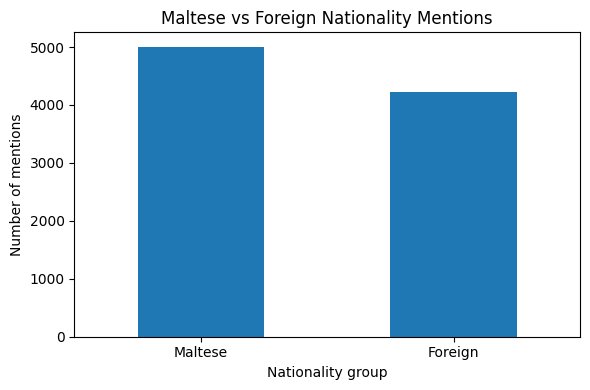

nationality_group
Maltese    5003
Foreign    4225
Name: count, dtype: int64

In [13]:
mentions = pd.read_csv("Data/Articles/Output/Articles_pattern_rule_mentions.csv")

mentions["nationality_group"] = mentions["code"].apply(
    lambda x: "Maltese" if x == "MLT" else "Foreign"
)


group_counts = mentions["nationality_group"].value_counts()

plt.figure(figsize=(6, 4))
group_counts.plot(kind="bar")
plt.title("Maltese vs Foreign Nationality Mentions")
plt.xlabel("Nationality group")
plt.ylabel("Number of mentions")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

mentions["nationality_group"].value_counts()

### Sentiment

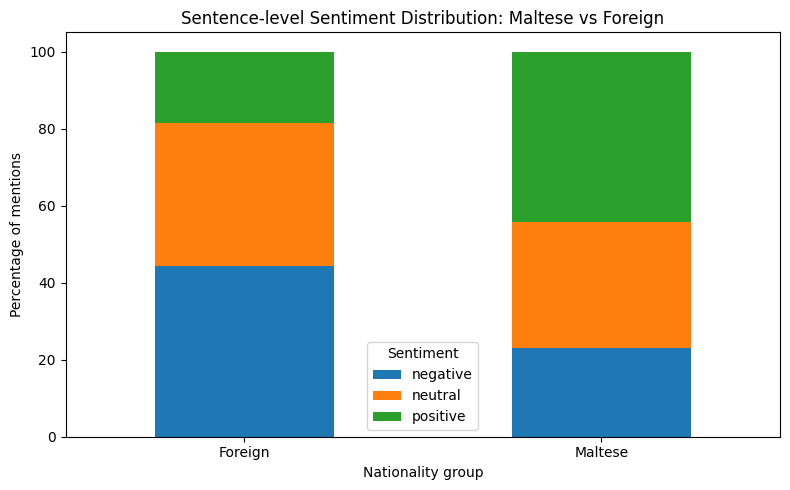

sentiment_sentence_label,negative,neutral,positive
nationality_group,,,
Foreign,44.38,37.18,18.44
Maltese,23.11,32.72,44.17


In [9]:
sentiment_order = ["negative", "neutral", "positive"]

sentiment_group = (
    mentions
    .groupby(["nationality_group", "sentiment_sentence_label"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=sentiment_order)
)

sentiment_group_pct = sentiment_group.div(sentiment_group.sum(axis=1), axis=0) * 100

sentiment_group_pct.plot(kind="bar", stacked=True, figsize=(8, 5))
plt.title("Sentence-level Sentiment Distribution: Maltese vs Foreign")
plt.xlabel("Nationality group")
plt.ylabel("Percentage of mentions")
plt.xticks(rotation=0)
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

sentiment_group_pct.round(2)

### Framing

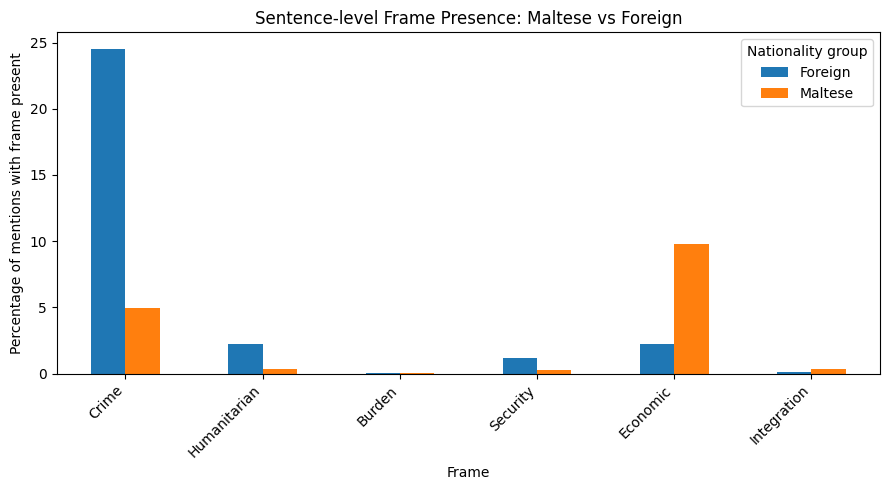

,Crime,Humanitarian,Burden,Security,Economic,Integration
nationality_group,,,,,,
Foreign,24.54,2.22,0.02,1.21,2.20,0.09
Maltese,4.98,0.38,0.06,0.28,9.75,0.38


In [10]:
frame_cols = [
    "sent_crime_frame",
    "sent_humanitarian_frame",
    "sent_burden_frame",
    "sent_security_frame",
    "sent_economic_frame",
    "sent_integration_frame"
]

frame_labels = {
    "sent_crime_frame": "Crime",
    "sent_humanitarian_frame": "Humanitarian",
    "sent_burden_frame": "Burden",
    "sent_security_frame": "Security",
    "sent_economic_frame": "Economic",
    "sent_integration_frame": "Integration"
}

frame_group = mentions.groupby("nationality_group")[frame_cols].mean() * 100
frame_group = frame_group.rename(columns=frame_labels)

frame_group.T.plot(kind="bar", figsize=(9, 5))
plt.title("Sentence-level Frame Presence: Maltese vs Foreign")
plt.xlabel("Frame")
plt.ylabel("Percentage of mentions with frame present")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Nationality group")
plt.tight_layout()
plt.show()

frame_group.round(2)

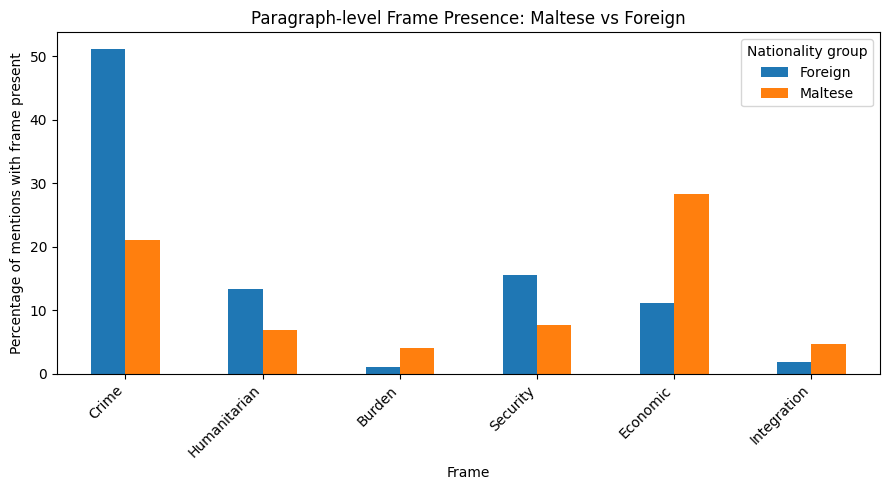

,Crime,Humanitarian,Burden,Security,Economic,Integration
nationality_group,,,,,,
Foreign,51.20,13.33,1.04,15.55,11.20,1.85
Maltese,21.01,6.90,4.08,7.66,28.26,4.72


In [11]:
frame_cols = [
    "para_crime_frame",
    "para_humanitarian_frame",
    "para_burden_frame",
    "para_security_frame",
    "para_economic_frame",
    "para_integration_frame"
]

frame_labels = {
    "para_crime_frame": "Crime",
    "para_humanitarian_frame": "Humanitarian",
    "para_burden_frame": "Burden",
    "para_security_frame": "Security",
    "para_economic_frame": "Economic",
    "para_integration_frame": "Integration"
}

frame_group = mentions.groupby("nationality_group")[frame_cols].mean() * 100
frame_group = frame_group.rename(columns=frame_labels)

frame_group.T.plot(kind="bar", figsize=(9, 5))
plt.title("Paragraph-level Frame Presence: Maltese vs Foreign")
plt.xlabel("Frame")
plt.ylabel("Percentage of mentions with frame present")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Nationality group")
plt.tight_layout()
plt.show()

frame_group.round(2)

## Continental based Analysis

### Mapping

In [29]:
"""
Mapping of ISO3 country codes to continents, 
based on the nationalities extracted from 
Articles_eval_mentions_summary.csv.
"""
iso3_to_continent = {
    # Europe
    "MLT": "Europe",
    "ITA": "Europe",
    "GBR": "Europe",
    "ALB": "Europe",
    "UKR": "Europe",
    "FRA": "Europe",
    "SRB": "Europe",
    "DEU": "Europe",
    "ROU": "Europe",
    "POL": "Europe",
    "RUS": "Europe",
    "ESP": "Europe",
    "BGR": "Europe",
    "PRT": "Europe",
    "MKD": "Europe",
    "HRV": "Europe",
    "IRL": "Europe",
    "HUN": "Europe",
    "BEL": "Europe",
    "GRC": "Europe",
    "NLD": "Europe",
    "FIN": "Europe",
    "NOR": "Europe",
    "DNK": "Europe",
    "SWE": "Europe",
    "AUT": "Europe",
    "LVA": "Europe",
    "GEO": "Europe",
    "LUX": "Europe",
    "LTU": "Europe",
    "MNE": "Europe",
    "SVK": "Europe",
    "CHE": "Europe",
    "SVN": "Europe",
    "CZE": "Europe",
    "ISL": "Europe",
    "EST": "Europe",
    "MDA": "Europe",
    "JEY": "Europe",

    # Asia
    "PSE": "Asia",
    "IND": "Asia",
    "SYR": "Asia",
    "NPL": "Asia",
    "JPN": "Asia",
    "TUR": "Asia",
    "CHN": "Asia",
    "PHL": "Asia",
    "PAK": "Asia",
    "BGD": "Asia",
    "ISR": "Asia",
    "AFG": "Asia",
    "THA": "Asia",
    "LBN": "Asia",
    "IDN": "Asia",
    "MYS": "Asia",
    "IRN": "Asia",
    "VNM": "Asia",
    "IRQ": "Asia",
    "YEM": "Asia",
    "QAT": "Asia",
    "MDV": "Asia",
    "JOR": "Asia",
    "SAU": "Asia",

    # Africa
    "LBY": "Africa",
    "EGY": "Africa",
    "SOM": "Africa",
    "MAR": "Africa",
    "NGA": "Africa",
    "ETH": "Africa",
    "SDN": "Africa",
    "GHA": "Africa",
    "GMB": "Africa",
    "TUN": "Africa",
    "ERI": "Africa",
    "DZA": "Africa",
    "SEN": "Africa",
    "MLI": "Africa",
    "CMR": "Africa",
    "GIN": "Africa",
    "TZA": "Africa",
    "KEN": "Africa",
    "NER": "Africa",
    "TCD": "Africa",

    # North America
    "USA": "North America",
    "CAN": "North America",
    "MEX": "North America",
    "CUB": "North America",
    "JAM": "North America",

    # South America
    "COL": "South America",
    "BRA": "South America",
    "VEN": "South America",
    "ARG": "South America",
    "ECU": "South America",
    "CHL": "South America",

    # Oceania
    "AUS": "Oceania",
    "VUT": "Oceania",
}

mentions["continent"] = mentions["code"].map(iso3_to_continent)

# Check whether any captured codes were not mapped
unmapped_codes = sorted(mentions.loc[mentions["continent"].isna(), "code"].dropna().unique())

print("Unmapped ISO3 codes:", unmapped_codes)

Unmapped ISO3 codes: []


### Counts (Excl. Maltese)

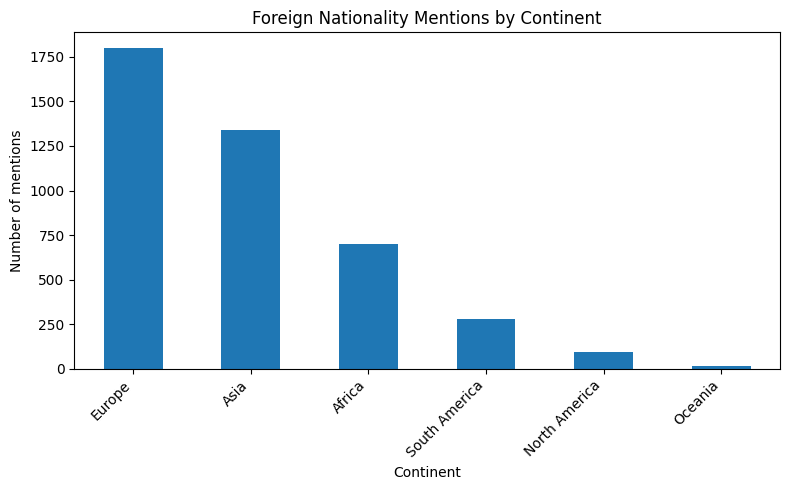

continent
Europe           1798
Asia             1337
Africa            700
South America     279
North America      95
Oceania            16
Name: count, dtype: int64

In [ ]:
foreign_mentions = mentions[mentions["code"] != "MLT"].copy()

foreign_continent_counts = (
    foreign_mentions["continent"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
foreign_continent_counts.plot(kind="bar")z
plt.title("Foreign Nationality Mentions by Continent")
plt.xlabel("Continent")
plt.ylabel("Number of mentions")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

foreign_continent_counts

### Sentiment

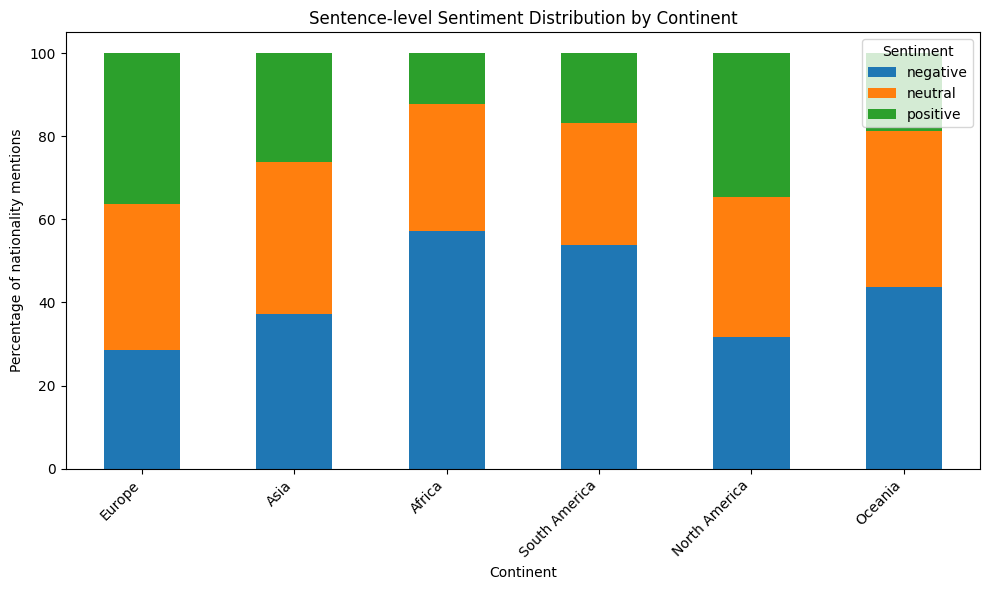

sentiment_sentence_label,negative,neutral,positive
continent,,,
Europe,28.60,35.05,36.35
Asia,37.25,36.65,26.10
Africa,57.29,30.57,12.14
South America,53.76,29.39,16.85
North America,31.58,33.68,34.74
Oceania,43.75,37.50,18.75


In [22]:
sentiment_order = ["negative", "neutral", "positive"]

sentiment_by_continent = (
    mentions
    .groupby(["continent", "sentiment_sentence_label"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=sentiment_order)
)

sentiment_by_continent_pct = (
    sentiment_by_continent
    .div(sentiment_by_continent.sum(axis=1), axis=0) * 100
)

sentiment_by_continent_pct = sentiment_by_continent_pct.loc[
    foreign_continent_counts.index
]

sentiment_by_continent_pct.plot(kind="bar", stacked=True, figsize=(10, 6))
plt.title("Sentence-level Sentiment Distribution by Continent")
plt.xlabel("Continent")
plt.ylabel("Percentage of nationality mentions")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

sentiment_by_continent_pct.round(2)

### Framing

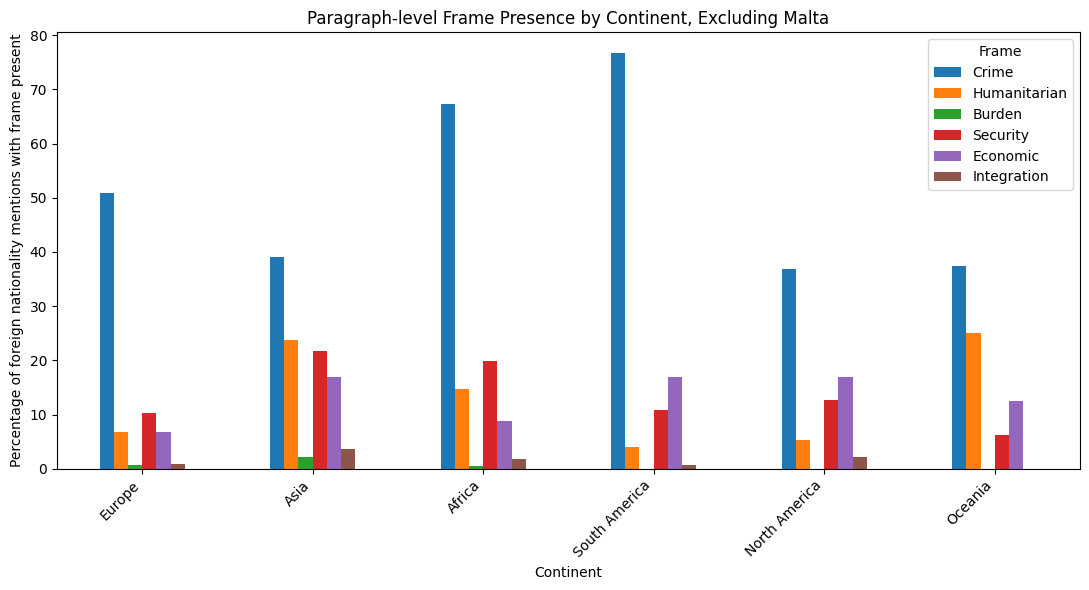

,Crime,Humanitarian,Burden,Security,Economic,Integration
continent,,,,,,
Europe,50.83,6.79,0.61,10.29,6.73,0.78
Asia,39.12,23.78,2.24,21.69,16.90,3.59
Africa,67.29,14.71,0.43,19.86,8.71,1.71
South America,76.70,3.94,0.00,10.75,16.85,0.72
North America,36.84,5.26,0.00,12.63,16.84,2.11
Oceania,37.50,25.00,0.00,6.25,12.50,0.00


In [25]:
frame_cols = [
    "para_crime_frame",
    "para_humanitarian_frame",
    "para_burden_frame",
    "para_security_frame",
    "para_economic_frame",
    "para_integration_frame"
]

frame_labels = {
    "para_crime_frame": "Crime",
    "para_humanitarian_frame": "Humanitarian",
    "para_burden_frame": "Burden",
    "para_security_frame": "Security",
    "para_economic_frame": "Economic",
    "para_integration_frame": "Integration"
}

foreign_frame_by_continent = foreign_mentions.groupby("continent")[frame_cols].mean() * 100
foreign_frame_by_continent = foreign_frame_by_continent.rename(columns=frame_labels)

foreign_frame_by_continent = foreign_frame_by_continent.loc[
    foreign_continent_counts.index
]

foreign_frame_by_continent.plot(kind="bar", figsize=(11, 6))
plt.title("Paragraph-level Frame Presence by Continent, Excluding Malta")
plt.xlabel("Continent")
plt.ylabel("Percentage of foreign nationality mentions with frame present")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Frame")
plt.tight_layout()
plt.show()

foreign_frame_by_continent.round(2)

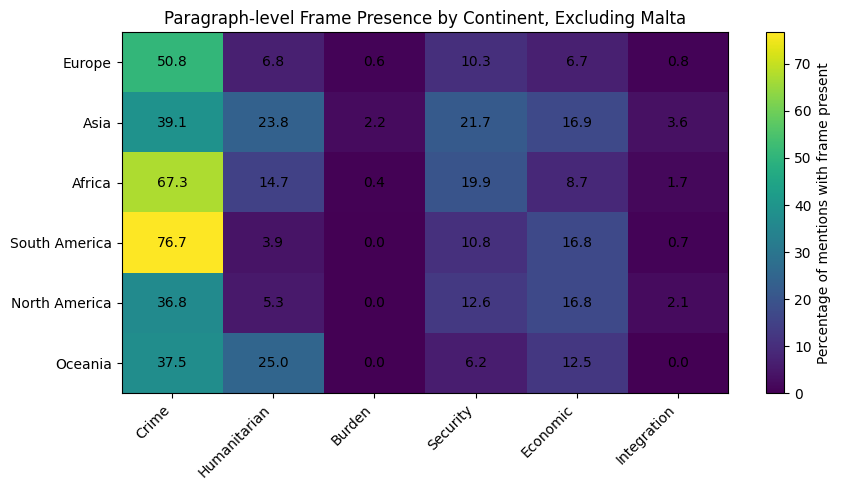

In [28]:
fig, ax = plt.subplots(figsize=(9, 5))

im = ax.imshow(foreign_frame_by_continent, aspect="auto")
plt.colorbar(im, ax=ax, label="Percentage of mentions with frame present")

ax.set_xticks(range(len(foreign_frame_by_continent.columns)))
ax.set_xticklabels(foreign_frame_by_continent.columns, rotation=45, ha="right")

ax.set_yticks(range(len(foreign_frame_by_continent.index)))
ax.set_yticklabels(foreign_frame_by_continent.index)

for i in range(foreign_frame_by_continent.shape[0]):
    for j in range(foreign_frame_by_continent.shape[1]):
        ax.text(
            j,
            i,
            f"{foreign_frame_by_continent.iloc[i, j]:.1f}",
            ha="center",
            va="center"
        )

ax.set_title("Paragraph-level Frame Presence by Continent, Excluding Malta")
plt.tight_layout()
plt.show()

## Top 20 mentions

In [7]:
df = pd.read_csv("Data/Articles/Output/Articles_pattern_rule_mentions.csv")

frames = ["crime", "humanitarian", "burden", "security", "economic", "integration"]
frame_cols = [f"para_{f}_frame" for f in frames]

for col in frame_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

top_nationalities = (
    df.groupby("code")
    .agg(
        mention_count=("code", "count"),
        article_count=("article_id", "nunique"),

        avg_negative=("sentiment_sentence_negative", "mean"),
        avg_neutral=("sentiment_sentence_neutral", "mean"),
        avg_positive=("sentiment_sentence_positive", "mean"),

        crime_mentions=("para_crime_frame", "sum"),
        humanitarian_mentions=("para_humanitarian_frame", "sum"),
        burden_mentions=("para_burden_frame", "sum"),
        security_mentions=("para_security_frame", "sum"),
        economic_mentions=("para_economic_frame", "sum"),
        integration_mentions=("para_integration_frame", "sum"),
    )
    .reset_index()
)

sentiment_cols = ["avg_negative", "avg_neutral", "avg_positive"]

top_nationalities["dominant_sentiment"] = (
    top_nationalities[sentiment_cols]
    .idxmax(axis=1)
    .str.replace("avg_", "")
)

frame_summary_cols = [
    "crime_mentions",
    "humanitarian_mentions",
    "burden_mentions",
    "security_mentions",
    "economic_mentions",
    "integration_mentions"
]

def get_most_popular_frame(row):
    counts = row[frame_summary_cols]

    if counts.max() == 0:
        return "No dominant frame"

    return counts.idxmax().replace("_mentions", "")

top_nationalities["most_popular_frame"] = top_nationalities.apply(
    get_most_popular_frame,
    axis=1
)

top_20_table = (
    top_nationalities
    .sort_values("mention_count", ascending=False)
    .head(20)
)

top_20_table[["avg_negative", "avg_neutral", "avg_positive"]] = (
    top_20_table[["avg_negative", "avg_neutral", "avg_positive"]]
    .round(3)
)

top_20_table = top_20_table[
    [
        "code",
        "mention_count",
        "article_count",
        "avg_negative",
        "avg_neutral",
        "avg_positive",
        "dominant_sentiment",
        "most_popular_frame",
    ]
]

top_20_table

,code,mention_count,article_count,avg_negative,avg_neutral,avg_positive,dominant_sentiment,most_popular_frame
60,MLT,5003,3597,0.228,0.325,0.447,positive,economic
72,PSE,335,233,0.318,0.130,0.552,positive,humanitarian
43,ITA,316,234,0.374,0.475,0.151,neutral,crime
37,IND,260,175,0.372,0.449,0.179,neutral,crime
28,GBR,234,181,0.317,0.564,0.119,neutral,crime
14,COL,224,161,0.524,0.300,0.175,negative,crime
84,SYR,197,141,0.467,0.368,0.164,negative,crime
50,LBY,194,169,0.577,0.234,0.189,negative,crime
1,ALB,146,118,0.436,0.466,0.098,neutral,crime
90,UKR,135,102,0.237,0.197,0.567,positive,security


## General results

### Sentiment x Framing

In [30]:
frame_cols = [
    "para_crime_frame",
    "para_humanitarian_frame",
    "para_burden_frame",
    "para_security_frame",
    "para_economic_frame",
    "para_integration_frame"
]

frame_names = {
    "para_crime_frame": "Crime",
    "para_humanitarian_frame": "Humanitarian",
    "para_burden_frame": "Burden",
    "para_security_frame": "Security",
    "para_economic_frame": "Economic",
    "para_integration_frame": "Integration"
}

In [31]:
sentiment_order = ["negative", "neutral", "positive"]

rows = []

for frame_col in frame_cols:
    frame_data = mentions[mentions[frame_col] == 1]

    sentiment_counts = (
        frame_data["sentiment_sentence_label"]
        .value_counts()
        .reindex(sentiment_order, fill_value=0)
    )

    sentiment_pct = sentiment_counts / sentiment_counts.sum() * 100

    for sentiment in sentiment_order:
        rows.append({
            "frame": frame_names[frame_col],
            "sentiment": sentiment,
            "percentage": sentiment_pct[sentiment],
            "count": sentiment_counts[sentiment]
        })

frame_sentiment_df = pd.DataFrame(rows)

frame_sentiment_df

,frame,sentiment,percentage,count
0,Crime,negative,62.787803,2018
1,Crime,neutral,22.028625,708
2,Crime,positive,15.183572,488
3,Humanitarian,negative,30.616740,278
4,Humanitarian,neutral,29.515419,268
5,Humanitarian,positive,39.867841,362
6,Burden,negative,29.032258,72
7,Burden,neutral,25.000000,62
8,Burden,positive,45.967742,114
9,Security,negative,40.673077,423


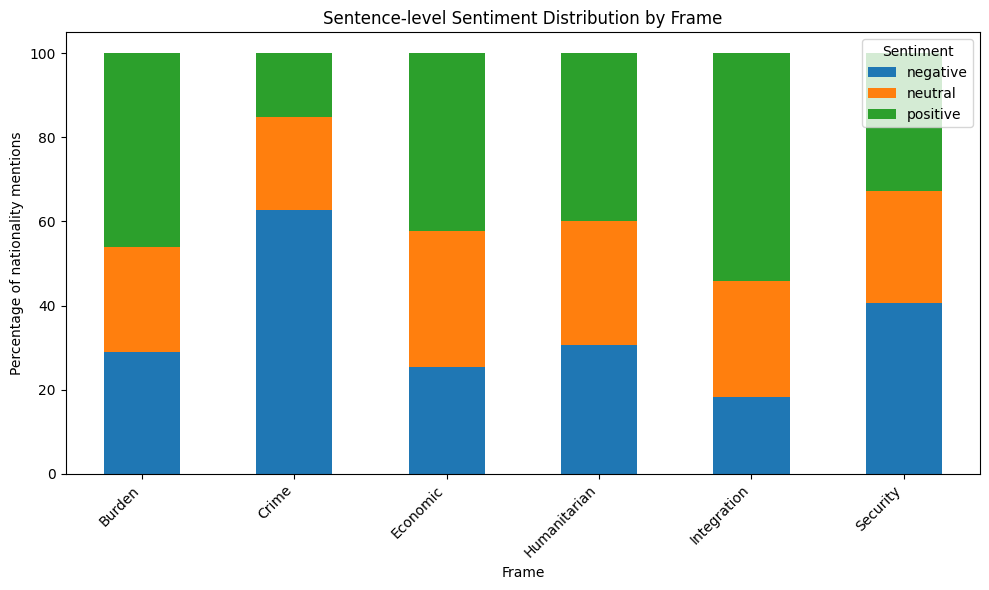

In [32]:
frame_sentiment_pivot = frame_sentiment_df.pivot(
    index="frame",
    columns="sentiment",
    values="percentage"
)

frame_sentiment_pivot = frame_sentiment_pivot[sentiment_order]

frame_sentiment_pivot.plot(kind="bar", stacked=True, figsize=(10, 6))

plt.title("Sentence-level Sentiment Distribution by Frame")
plt.xlabel("Frame")
plt.ylabel("Percentage of nationality mentions")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

### Sentiment Granularities Comparison

In [35]:
articles = pd.read_csv("Data/Articles/Output/Articles_nationalities_enriched.csv")

article_sentiment = articles[[
    "article_id",
    "sent_article_label"
]].drop_duplicates()

In [36]:
mentions_with_article_sentiment = mentions.merge(
    article_sentiment,
    on="article_id",
    how="left"
)

mentions_with_article_sentiment[[
    "article_id",
    "sentiment_sentence_label",
    "sent_article_label"
]].head()

,article_id,sentiment_sentence_label,sent_article_label
0,301048,negative,negative
1,77510,positive,positive
2,125466,negative,negative
3,128627,neutral,neutral
4,162375,neutral,neutral


In [37]:
article_sentence_table = pd.crosstab(
    mentions_with_article_sentiment["sent_article_label"],
    mentions_with_article_sentiment["sentiment_sentence_label"],
    rownames=["Article-level sentiment"],
    colnames=["Sentence-level sentiment"]
).reindex(
    index=sentiment_order,
    columns=sentiment_order,
    fill_value=0
)

article_sentence_table

Sentence-level sentiment,negative,neutral,positive
Article-level sentiment,,,
negative,2503,274,215
neutral,329,2642,396
positive,199,292,2378


In [38]:
article_sentence_pct = (
    article_sentence_table
    .div(article_sentence_table.sum(axis=1), axis=0) * 100
)

article_sentence_pct.round(2)

Sentence-level sentiment,negative,neutral,positive
Article-level sentiment,,,
negative,83.66,9.16,7.19
neutral,9.77,78.47,11.76
positive,6.94,10.18,82.89


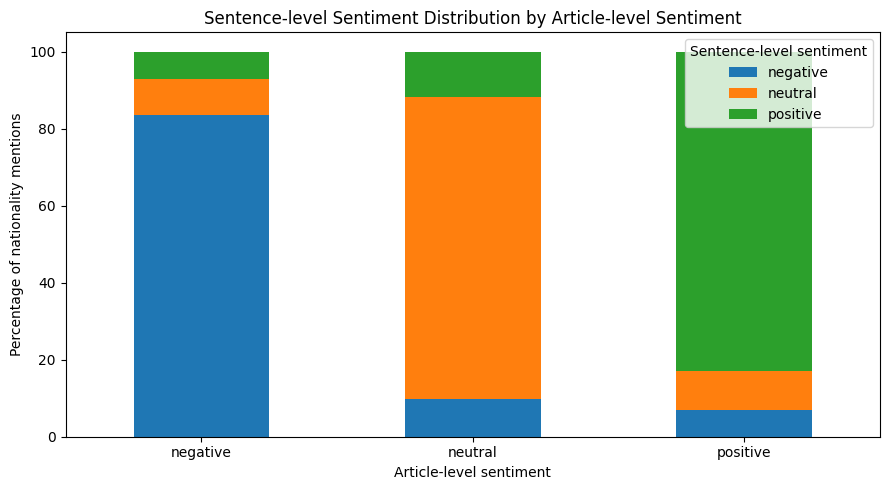

In [39]:
article_sentence_pct.plot(kind="bar", stacked=True, figsize=(9, 5))

plt.title("Sentence-level Sentiment Distribution by Article-level Sentiment")
plt.xlabel("Article-level sentiment")
plt.ylabel("Percentage of nationality mentions")
plt.xticks(rotation=0)
plt.legend(title="Sentence-level sentiment")
plt.tight_layout()
plt.show()

### Sentiment mismatch

In [40]:
mentions_with_article_sentiment["sentiment_match"] = (
    mentions_with_article_sentiment["sentiment_sentence_label"]
    == mentions_with_article_sentiment["sent_article_label"]
)

match_rate = mentions_with_article_sentiment["sentiment_match"].mean() * 100

print(f"Article-level and sentence-level sentiment match in {match_rate:.2f}% of mentions.")

Article-level and sentence-level sentiment match in 81.52% of mentions.


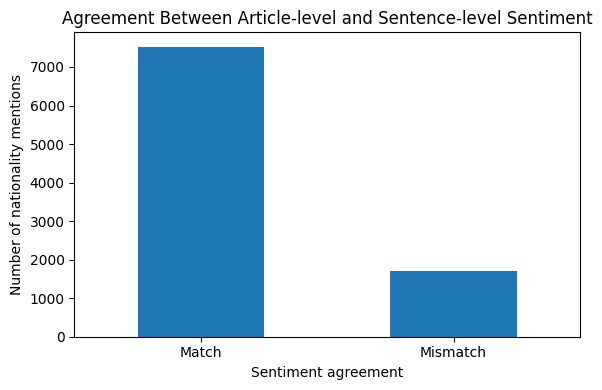

sentiment_match
Match       7523
Mismatch    1705
Name: count, dtype: int64

In [43]:
match_counts = (
    mentions_with_article_sentiment["sentiment_match"]
    .map({True: "Match", False: "Mismatch"})
    .value_counts()
)

plt.figure(figsize=(6, 4))
match_counts.plot(kind="bar")

plt.title("Agreement Between Article-level and Sentence-level Sentiment")
plt.xlabel("Sentiment agreement")
plt.ylabel("Number of nationality mentions")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

match_counts

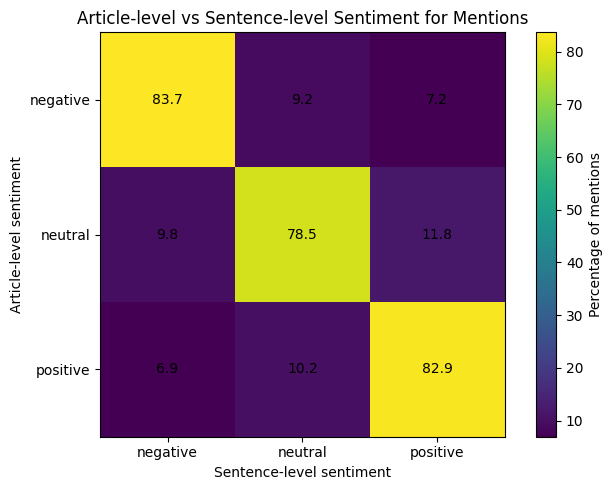

In [47]:
fig, ax = plt.subplots(figsize=(7, 5))

im = ax.imshow(article_sentence_pct)

plt.colorbar(im, ax=ax, label="Percentage of mentions")

ax.set_xticks(range(len(sentiment_order)))
ax.set_xticklabels(sentiment_order)

ax.set_yticks(range(len(sentiment_order)))
ax.set_yticklabels(sentiment_order)

for i in range(article_sentence_pct.shape[0]):
    for j in range(article_sentence_pct.shape[1]):
        ax.text(
            j,
            i,
            f"{article_sentence_pct.iloc[i, j]:.1f}",
            ha="center",
            va="center"
        )

ax.set_xlabel("Sentence-level sentiment")
ax.set_ylabel("Article-level sentiment")
ax.set_title("Article-level vs Sentence-level Sentiment for Mentions")
plt.tight_layout()
plt.show()

### Framing Sentiment Mismatch Analysis

In [45]:
frame_match_rows = []

for frame_col in frame_cols:
    frame_data = mentions_with_article_sentiment[
        mentions_with_article_sentiment[frame_col] == 1
    ]

    match_pct = frame_data["sentiment_match"].mean() * 100
    mismatch_pct = 100 - match_pct

    frame_match_rows.append({
        "frame": frame_names[frame_col],
        "match_percentage": match_pct,
        "mismatch_percentage": mismatch_pct,
        "mentions": len(frame_data)
    })

frame_match_df = pd.DataFrame(frame_match_rows)

frame_match_df

,frame,match_percentage,mismatch_percentage,mentions
0,Crime,82.762912,17.237088,3214
1,Humanitarian,74.889868,25.110132,908
2,Burden,76.209677,23.790323,248
3,Security,76.057692,23.942308,1040
4,Economic,76.523582,23.476418,1887
5,Integration,75.796178,24.203822,314


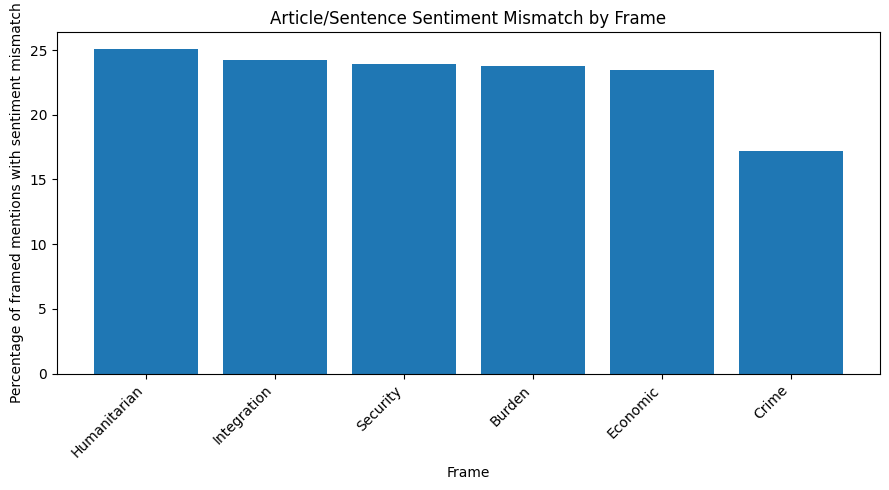

,frame,match_percentage,mismatch_percentage,mentions
1,Humanitarian,74.89,25.11,908
5,Integration,75.80,24.20,314
3,Security,76.06,23.94,1040
2,Burden,76.21,23.79,248
4,Economic,76.52,23.48,1887
0,Crime,82.76,17.24,3214


In [46]:
frame_match_df_sorted = frame_match_df.sort_values(
    "mismatch_percentage",
    ascending=False
)

plt.figure(figsize=(9, 5))
plt.bar(
    frame_match_df_sorted["frame"],
    frame_match_df_sorted["mismatch_percentage"]
)

plt.title("Article/Sentence Sentiment Mismatch by Frame")
plt.xlabel("Frame")
plt.ylabel("Percentage of framed mentions with sentiment mismatch")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

frame_match_df_sorted.round(2)

# EXTRA RESULTS

Taken for my own validation of results

## FRAMING ANALYSIS

This section was used during development to understand framing results and iteratively alter the framing lexicons

In [ ]:
# Create selected frame labels for mention-level data

mention_sent_frame_cols = [
    "sent_crime_frame",
    "sent_humanitarian_frame",
    "sent_burden_frame",
    "sent_security_frame",
    "sent_economic_frame",
    "sent_integration_frame",
]

mention_para_frame_cols = [
    "para_crime_frame",
    "para_humanitarian_frame",
    "para_burden_frame",
    "para_security_frame",
    "para_economic_frame",
    "para_integration_frame",
]

def extract_active_frames(row, cols, prefix_to_remove):
    active = []
    for c in cols:
        if c in row.index and pd.notna(row[c]) and int(row[c]) == 1:
            active.append(c.replace(prefix_to_remove, ""))
    return active

out_mentions_df["sentence_frames_selected"] = out_mentions_df.apply(
    lambda row: extract_active_frames(row, mention_sent_frame_cols, "sent_"),
    axis=1
)

out_mentions_df["paragraph_frames_selected"] = out_mentions_df.apply(
    lambda row: extract_active_frames(row, mention_para_frame_cols, "para_"),
    axis=1
)

out_mentions_df["sentence_primary_frame"] = out_mentions_df["sentence_frames_selected"].apply(
    lambda x: x[0] if len(x) > 0 else pd.NA
)

out_mentions_df["paragraph_primary_frame"] = out_mentions_df["paragraph_frames_selected"].apply(
    lambda x: x[0] if len(x) > 0 else pd.NA
)

out_mentions_df[[
    "article_id", "code", "surface", "sentence",
    "sentence_frames_selected", "paragraph_frames_selected",
    "sentence_primary_frame", "paragraph_primary_frame"
]].head(10)

,article_id,code,surface,sentence,sentence_frames_selected,paragraph_frames_selected,sentence_primary_frame,paragraph_primary_frame
0,301048,MLT,Maltese,David Walliams was allegedly paid more for one...,[],[burden_frame],NaN,burden_frame
1,310544,MLT,Maltese,The Maltese economy maintains its growth momen...,[economic_frame],[economic_frame],economic_frame,economic_frame
2,310544,MLT,Maltese,The Commission noted that after achieving 5.0%...,[economic_frame],[economic_frame],economic_frame,economic_frame
3,310544,MLT,Maltese,Energy prices are expected to remain stable al...,[],[economic_frame],NaN,economic_frame
4,77510,MLT,Gozitans,"I will ensure that as the economy grows, this ...",[],[economic_frame],NaN,economic_frame
5,77510,MLT,Maltese,After exalting the positive qualities of the M...,[economic_frame],[economic_frame],economic_frame,economic_frame
6,483029,MLT,Maltese,"Humanists Malta, a Maltese NGO is one of 28 NG...",[],[],NaN,NaN
7,310638,MLT,Maltese,Man to run 100km around Maltese coast in aid o...,[],[],NaN,NaN
8,310638,MLT,Maltese,Athlete Miguel Mifsud will be running 100 kilo...,[],[humanitarian_frame],NaN,humanitarian_frame
9,310638,MLT,Maltese,The organisation hopes that more good can cont...,[humanitarian_frame],[humanitarian_frame],humanitarian_frame,humanitarian_frame


In [ ]:
# Create selected frame labels for article-level data

article_sent_frame_cols = [
    "sent_crime_frame",
    "sent_humanitarian_frame",
    "sent_burden_frame",
    "sent_security_frame",
    "sent_economic_frame",
    "sent_integration_frame",
]

article_para_frame_cols = [
    "para_crime_frame",
    "para_humanitarian_frame",
    "para_burden_frame",
    "para_security_frame",
    "para_economic_frame",
    "para_integration_frame",
]

article_full_frame_cols = [
    "crime_frame",
    "humanitarian_frame",
    "burden_frame",
    "security_frame",
    "economic_frame",
    "integration_frame",
]

def extract_active_article_frames(row, cols, prefix=""):
    active = []
    for c in cols:
        if c in row.index and pd.notna(row[c]) and int(row[c]) == 1:
            label = c.replace(prefix, "") if prefix else c
            active.append(label)
    return active

out_df["sent_frames_selected"] = out_df.apply(
    lambda row: extract_active_article_frames(row, article_sent_frame_cols, "sent_"),
    axis=1
)

out_df["para_frames_selected"] = out_df.apply(
    lambda row: extract_active_article_frames(row, article_para_frame_cols, "para_"),
    axis=1
)

out_df["article_frames_selected"] = out_df.apply(
    lambda row: extract_active_article_frames(row, article_full_frame_cols, ""),
    axis=1
)

out_df["sent_primary_frame"] = out_df["sent_frames_selected"].apply(
    lambda x: x[0] if len(x) > 0 else pd.NA
)

out_df["para_primary_frame"] = out_df["para_frames_selected"].apply(
    lambda x: x[0] if len(x) > 0 else pd.NA
)

out_df["article_primary_frame"] = out_df["article_frames_selected"].apply(
    lambda x: x[0] if len(x) > 0 else pd.NA
)

out_df[[
    "article_id",
    "sent_frames_selected",
    "para_frames_selected",
    "article_frames_selected",
    "sent_primary_frame",
    "para_primary_frame",
    "article_primary_frame"
]].head(10)

,article_id,sent_frames_selected,para_frames_selected,article_frames_selected,sent_primary_frame,para_primary_frame,article_primary_frame
0,299560,[],[],[],NaN,NaN,NaN
1,301048,[],[burden_frame],[burden_frame],NaN,burden_frame,burden_frame
2,310544,[economic_frame],[economic_frame],[economic_frame],economic_frame,economic_frame,economic_frame
3,310584,[],[],[],NaN,NaN,NaN
4,77510,[economic_frame],[economic_frame],[economic_frame],economic_frame,economic_frame,economic_frame
5,238351,[],[],[economic_frame],NaN,NaN,economic_frame
6,483029,[],[],[humanitarian_frame],NaN,NaN,humanitarian_frame
7,80299,[],[],[],NaN,NaN,NaN
8,310638,[humanitarian_frame],[humanitarian_frame],[humanitarian_frame],humanitarian_frame,humanitarian_frame,humanitarian_frame
9,218531,[],[],[crime_frame],NaN,NaN,crime_frame


In [ ]:
# Coverage of framing

mentions_with_sentence_frame = (out_mentions_df["sentence_frames_selected"].apply(len) > 0).mean() * 100
mentions_with_paragraph_frame = (out_mentions_df["paragraph_frames_selected"].apply(len) > 0).mean() * 100

articles_with_sent_frame = (out_df["sent_frames_selected"].apply(len) > 0).mean() * 100
articles_with_para_frame = (out_df["para_frames_selected"].apply(len) > 0).mean() * 100
articles_with_full_frame = (out_df["article_frames_selected"].apply(len) > 0).mean() * 100

print(f"Mentions with >=1 sentence frame: {mentions_with_sentence_frame:.2f}%")
print(f"Mentions with >=1 paragraph frame: {mentions_with_paragraph_frame:.2f}%")
print(f"Articles with >=1 aggregated sentence frame: {articles_with_sent_frame:.2f}%")
print(f"Articles with >=1 aggregated paragraph frame: {articles_with_para_frame:.2f}%")
print(f"Articles with >=1 full-article frame: {articles_with_full_frame:.2f}%")

Mentions with >=1 sentence frame: 9.63%
Mentions with >=1 paragraph frame: 47.21%
Articles with >=1 aggregated sentence frame: 5.82%
Articles with >=1 aggregated paragraph frame: 15.99%
Articles with >=1 full-article frame: 38.93%


In [ ]:
# Inspect unframed mentions

no_sent_frame = out_mentions_df[out_mentions_df["sentence_frames_selected"].apply(len) == 0]
no_para_frame = out_mentions_df[out_mentions_df["paragraph_frames_selected"].apply(len) == 0]

print("No sentence frame:", len(no_sent_frame))
print("No paragraph frame:", len(no_para_frame))

no_sent_frame[["article_id", "code", "surface", "sentence", "paragraph"]].head(20)

No sentence frame: 51775
No paragraph frame: 30245


,article_id,code,surface,sentence,paragraph
0,301048,MLT,Maltese,David Walliams was allegedly paid more for one...,We will issue all the numbers after the film a...
3,310544,MLT,Maltese,Energy prices are expected to remain stable al...,The Maltese economy maintains its growth momen...
4,77510,MLT,Gozitans,"I will ensure that as the economy grows, this ...",Robert Abela has pledged to continue addressin...
6,483029,MLT,Maltese,"Humanists Malta, a Maltese NGO is one of 28 NG...","Humanists Malta, a Maltese NGO is one of 28 NG..."
7,310638,MLT,Maltese,Man to run 100km around Maltese coast in aid o...,Man to run 100km around Maltese coast in aid o...
8,310638,MLT,Maltese,Athlete Miguel Mifsud will be running 100 kilo...,Athlete Miguel Mifsud will be running 100 kilo...
10,229680,ITA,Italian,"However, the separate accusation involving a 5...","Christmas is a time of merriment when friends,..."
11,229680,ITA,Italian,The alleged kickback was paid by a company lin...,"Christmas is a time of merriment when friends,..."
12,101554,MLT,Maltese,"However, [&] the funds originated from Vitals ...",A company that was granted an exclusive procur...
13,104619,ISR,Israelis,The council called for civilian welfare to be ...,The National Youth Council (KNZ) has expressed...


In [ ]:
# Inspect available framing columns in the article-level and mention-level dataframes

article_frame_cols = [c for c in out_df.columns if "frame" in c.lower()]
mention_frame_cols = [c for c in out_mentions_df.columns if "frame" in c.lower()]

print("ARTICLE-LEVEL FRAME COLUMNS")
for c in article_frame_cols:
    print(c)

print("\n" + "="*70 + "\n")

print("MENTION-LEVEL FRAME COLUMNS")
for c in mention_frame_cols:
    print(c)

ARTICLE-LEVEL FRAME COLUMNS
sent_crime_frame
sent_crime_frame_hits
sent_crime_frame_unique
sent_crime_frame_density
sent_humanitarian_frame
sent_humanitarian_frame_hits
sent_humanitarian_frame_unique
sent_humanitarian_frame_density
sent_burden_frame
sent_burden_frame_hits
sent_burden_frame_unique
sent_burden_frame_density
sent_security_frame
sent_security_frame_hits
sent_security_frame_unique
sent_security_frame_density
sent_economic_frame
sent_economic_frame_hits
sent_economic_frame_unique
sent_economic_frame_density
sent_integration_frame
sent_integration_frame_hits
sent_integration_frame_unique
sent_integration_frame_density
para_crime_frame
para_crime_frame_hits
para_crime_frame_unique
para_crime_frame_density
para_humanitarian_frame
para_humanitarian_frame_hits
para_humanitarian_frame_unique
para_humanitarian_frame_density
para_burden_frame
para_burden_frame_hits
para_burden_frame_unique
para_burden_frame_density
para_security_frame
para_security_frame_hits
para_security_frame_uni

In [ ]:
# Article-level frame prevalence

frames = [
    "crime_frame",
    "humanitarian_frame",
    "burden_frame",
    "security_frame",
    "economic_frame",
    "integration_frame",
]

article_frame_summary = pd.DataFrame({
    "frame": frames,
    "n_articles": [int(out_df[f].fillna(0).sum()) if f in out_df.columns else 0 for f in frames],
    "pct_articles": [
        float(out_df[f].fillna(0).mean() * 100) if f in out_df.columns else 0.0
        for f in frames
    ]
}).sort_values("pct_articles", ascending=False).reset_index(drop=True)

article_frame_summary

,frame,n_articles,pct_articles
0,crime_frame,12375,19.355293
1,economic_frame,8701,13.608921
2,security_frame,3813,5.963776
3,humanitarian_frame,3609,5.644707
4,integration_frame,2036,3.184434
5,burden_frame,1070,1.673549


In [ ]:
# Sentence-level framing prevalence across mentions

sent_frames = [f"sent_{fr}" for fr in frames if f"sent_{fr}" in out_mentions_df.columns]

mention_sent_frame_summary = pd.DataFrame({
    "frame": sent_frames,
    "n_mentions": [int(out_mentions_df[f].fillna(0).sum()) for f in sent_frames],
    "pct_mentions": [float(out_mentions_df[f].fillna(0).mean() * 100) for f in sent_frames]
}).sort_values("pct_mentions", ascending=False).reset_index(drop=True)

mention_sent_frame_summary

,frame,n_mentions,pct_mentions
0,sent_crime_frame,2862,4.995462
1,sent_economic_frame,1467,2.560567
2,sent_humanitarian_frame,846,1.476646
3,sent_security_frame,330,0.575997
4,sent_integration_frame,141,0.246108
5,sent_burden_frame,27,0.047127


In [ ]:
# Paragraph-level framing prevalence across mentions

para_frames = [f"para_{fr}" for fr in frames if f"para_{fr}" in out_mentions_df.columns]

mention_para_frame_summary = pd.DataFrame({
    "frame": para_frames,
    "n_mentions": [int(out_mentions_df[f].fillna(0).sum()) for f in para_frames],
    "pct_mentions": [float(out_mentions_df[f].fillna(0).mean() * 100) for f in para_frames]
}).sort_values("pct_mentions", ascending=False).reset_index(drop=True)

mention_para_frame_summary

,frame,n_mentions,pct_mentions
0,para_crime_frame,12308,21.482930
1,para_economic_frame,9555,16.677721
2,para_security_frame,7985,13.937373
3,para_humanitarian_frame,7528,13.139705
4,para_integration_frame,2217,3.869650
5,para_burden_frame,1166,2.035188


In [ ]:
# Framing rate by nationality (sentence-level)

min_mentions = 10  # adjust if needed

valid = out_mentions_df.copy()
valid = valid.dropna(subset=["code"])

grouped = valid.groupby("code")

nationality_frame_rows = []
for code, g in grouped:
    if len(g) < min_mentions:
        continue

    row = {
        "code": code,
        "n_mentions": len(g)
    }
    for fr in frames:
        col = f"sent_{fr}"
        if col in g.columns:
            row[f"{fr}_rate"] = float(g[col].fillna(0).mean())
    nationality_frame_rows.append(row)

nationality_frame_df = pd.DataFrame(nationality_frame_rows).sort_values(
    "n_mentions", ascending=False
).reset_index(drop=True)

nationality_frame_df.head(20)

,code,n_mentions,crime_frame_rate,humanitarian_frame_rate,burden_frame_rate,security_frame_rate,economic_frame_rate,integration_frame_rate
0,MLT,32381,0.026991,0.008307,0.000741,0.002224,0.038078,0.003551
1,PSE,2886,0.018711,0.080042,0.000000,0.014900,0.006930,0.000000
2,ITA,2450,0.079592,0.010612,0.000000,0.002857,0.003673,0.000000
3,ISR,2148,0.025605,0.062849,0.000000,0.019553,0.007449,0.000931
4,GBR,2117,0.034955,0.000945,0.000472,0.003307,0.004251,0.000945
5,RUS,1299,0.025404,0.010008,0.000770,0.017706,0.005389,0.000000
6,FRA,1089,0.038567,0.000918,0.000000,0.003673,0.002755,0.001837
7,USA,961,0.046826,0.005203,0.000000,0.004162,0.007284,0.000000
8,UKR,868,0.028802,0.016129,0.000000,0.014977,0.002304,0.001152
9,DEU,693,0.077922,0.010101,0.000000,0.002886,0.010101,0.001443


In [ ]:
# Top sentence-level frame per nationality

frame_rate_cols = [f"{fr}_rate" for fr in frames if f"{fr}_rate" in nationality_frame_df.columns]

top_frame_rows = []
for _, row in nationality_frame_df.iterrows():
    best_col = max(frame_rate_cols, key=lambda c: row.get(c, 0.0))
    top_frame_rows.append({
        "code": row["code"],
        "n_mentions": int(row["n_mentions"]),
        "top_frame": best_col.replace("_rate", ""),
        "top_frame_rate": float(row[best_col])
    })

top_frame_by_nationality = pd.DataFrame(top_frame_rows).sort_values(
    ["n_mentions", "top_frame_rate"], ascending=False
).reset_index(drop=True)

top_frame_by_nationality.head(20)

,code,n_mentions,top_frame,top_frame_rate
0,MLT,32381,economic_frame,0.038078
1,PSE,2886,humanitarian_frame,0.080042
2,ITA,2450,crime_frame,0.079592
3,ISR,2148,humanitarian_frame,0.062849
4,GBR,2117,crime_frame,0.034955
5,RUS,1299,crime_frame,0.025404
6,FRA,1089,crime_frame,0.038567
7,USA,961,crime_frame,0.046826
8,UKR,868,crime_frame,0.028802
9,DEU,693,crime_frame,0.077922


In [ ]:
# Mean sentence sentiment by frame

sentiment_by_frame_rows = []

for fr in frames:
    frame_col = f"sent_{fr}"
    if frame_col not in out_mentions_df.columns:
        continue

    g = out_mentions_df[out_mentions_df[frame_col] == 1].copy()
    if len(g) == 0:
        continue

    sentiment_by_frame_rows.append({
        "frame": fr,
        "n_mentions": len(g),
        "mean_negative": g["sentiment_sentence_negative"].mean() if "sentiment_sentence_negative" in g.columns else np.nan,
        "mean_neutral": g["sentiment_sentence_neutral"].mean() if "sentiment_sentence_neutral" in g.columns else np.nan,
        "mean_positive": g["sentiment_sentence_positive"].mean() if "sentiment_sentence_positive" in g.columns else np.nan,
    })

sentiment_by_frame_df = pd.DataFrame(sentiment_by_frame_rows).sort_values(
    "mean_negative", ascending=False
).reset_index(drop=True)

sentiment_by_frame_df

,frame,n_mentions,mean_negative,mean_neutral,mean_positive
0,crime_frame,2862,0.814535,0.081459,0.104006
1,burden_frame,27,0.617692,0.120456,0.261852
2,security_frame,330,0.428742,0.324306,0.246952
3,humanitarian_frame,846,0.266186,0.311642,0.422171
4,economic_frame,1467,0.188897,0.357644,0.453459
5,integration_frame,141,0.041654,0.325052,0.633294


In [ ]:
# Compare framed vs non-framed mentions

comparison_rows = []

for fr in frames:
    col = f"sent_{fr}"
    if col not in out_mentions_df.columns:
        continue

    framed = out_mentions_df[out_mentions_df[col] == 1]
    not_framed = out_mentions_df[out_mentions_df[col] == 0]

    comparison_rows.append({
        "frame": fr,
        "n_framed": len(framed),
        "n_not_framed": len(not_framed),
        "framed_mean_negative": framed["sentiment_sentence_negative"].mean() if "sentiment_sentence_negative" in framed.columns and len(framed) else np.nan,
        "not_framed_mean_negative": not_framed["sentiment_sentence_negative"].mean() if "sentiment_sentence_negative" in not_framed.columns and len(not_framed) else np.nan,
        "difference_negative": (
            framed["sentiment_sentence_negative"].mean() - not_framed["sentiment_sentence_negative"].mean()
            if "sentiment_sentence_negative" in framed.columns and len(framed) and len(not_framed)
            else np.nan
        )
    })

frame_sentiment_comparison = pd.DataFrame(comparison_rows).sort_values(
    "difference_negative", ascending=False
).reset_index(drop=True)

frame_sentiment_comparison

,frame,n_framed,n_not_framed,framed_mean_negative,not_framed_mean_negative,difference_negative
0,crime_frame,2862,54430,0.814535,0.196107,0.618428
1,burden_frame,27,57265,0.617692,0.226816,0.390876
2,security_frame,330,56962,0.428742,0.225831,0.202911
3,humanitarian_frame,846,56446,0.266186,0.226413,0.039773
4,economic_frame,1467,55825,0.188897,0.228002,-0.039105
5,integration_frame,141,57151,0.041654,0.227457,-0.185804


In [ ]:
# Frame co-occurrence matrix (article-level)

available_article_frames = [f for f in frames if f in out_df.columns]

cooccurrence = pd.DataFrame(index=available_article_frames, columns=available_article_frames)

for f1 in available_article_frames:
    for f2 in available_article_frames:
        cooccurrence.loc[f1, f2] = int(((out_df[f1] == 1) & (out_df[f2] == 1)).sum())

cooccurrence

,crime_frame,humanitarian_frame,burden_frame,security_frame,economic_frame,integration_frame
crime_frame,12375,913,175,1266,1465,171
humanitarian_frame,913,3609,109,691,631,308
burden_frame,175,109,1070,123,438,84
security_frame,1266,691,123,3813,904,197
economic_frame,1465,631,438,904,8701,585
integration_frame,171,308,84,197,585,2036


In [27]:
frames = [
    "crime_frame",
    "humanitarian_frame",
    "economic_frame",
    "security_frame",
    "integration_frame",
    "burden_frame",
]

for fr in frames:
    print("\n" + "="*80)
    print(fr)
    cols = ["article_id", "title", "subtitle", "top_image_caption", "content"]
    show_cols = [c for c in cols if c in out_df.columns] + [fr]
    sample = out_df[out_df[fr] == 1][show_cols].head(10)
    display(sample)


crime_frame


,article_id,title,subtitle,top_image_caption,content,crime_frame
9,218531,Robert Abela heaps praise on Chris Fearne: Co...,Prime Minister Robert Abela blames establishm...,Robert Abela addressing supporters at an event...,Robert Abela praised Chris Fearne and reiterat...,1
10,485631,Fugitive who disappeared in 2018 arrested when...,Man who disappeared in December 2018 while on ...,File photo,"A man who disappeared in December 2018, while ...",1
12,229680,[ANALYSIS] Jobgate: Wrapped for Christmas or s...,It took Robert Abela three weeks to dismissCla...,"Why did it take Abela so long to act, given th...","Christmas is a time of merriment when friends,...",1
19,117377,MaltaTodays journalists pick their story of t...,"It has been a year of breaking news, human sto...","2024 has been a year of breaking news, human s...",Executive Editor Kurt Sansone - Were publishi...,1
25,128627,"Muscat consultancies netted him 450,000 after ...","Former Prime Minister Joseph Muscat, who will ...",Former Prime Minister Joseph Muscat (Photo: Ja...,"Former prime minister Joseph Muscat, now charg...",1
29,132205,Justice minister criticises request for gaggin...,Justice Minister calls prosecutions request ...,Justice Minister Jonathan Attard (File photo),The prosecutions request to impose a gagging...,1
42,147048,"Its time up for Labour, Grech tells support...",Opposition leader Bernard Grech says Labour ca...,Opposition leader Bernard Grech,"2024-09-20, The reason government cannot clamp...",1
46,151197,Ministry denies disappearance of medical files...,"""It is more obvious than ever before that Agiu...",NaN,The Ministry for Social Policy has denied alle...,1
48,154677,Repubblika says government is intimidating civ...,Following Prime Minister Robert Abela's sugges...,NaN,NGO Repubblika expressed its disappointment ov...,1
51,161236,Independent inquiry launched after police offi...,Inquiry into 55-year-olds death will focus on...,NaN,An independent inquiry has been initiated to i...,1



humanitarian_frame


,article_id,title,subtitle,top_image_caption,content,humanitarian_frame
6,483029,European NGOs unite to petition EU Parliament ...,"During this legislature, Malta is set to have ...","Humanists Malta, a Maltese NGO is one of 28 NG...",A coalition of 28 organisations spanning acros...,1
8,310638,Man to run 100km around Maltese coast in aid o...,NaN,NaN,Athlete Miguel Mifsud will be running 100 kilo...,1
11,199897,Employers reiterate unwavering opposition to m...,No discussions on mandatory unionisation held ...,NaN,Maltas employers have come out in force again...,1
15,104619,Youth Council concerned over escalation of vio...,The National Youth Council (KNZ) is concerned ...,file image,The National Youth Council (KNZ) has expressed...,1
21,311044,Pride month is a time to act about LGBTIQ+ rig...,NaN,NaN,Pride month is a time to reflect on the rights...,1
36,138878,Borg reiterates calls for Russia to withdraw f...,Deputy Prime Minister Ian Borg is this week le...,Deputy Prime Minister and Minister for Foreign...,Deputy Prime Minister and Minister for Foreign...,1
68,189719,[WATCH] Abused by nuns: Victims describe child...,They spent their childhood in the Lourdes Home...,Roseanne Saliba grew up in the care of the Dom...,"In the quiet village of G'ajnsielem in Gozo, l...",1
69,306502,"NGO shocked Malta detained, isolated a Syria...",NaN,NaN,NGO aditus expressed shock that a Syrian woman...,1
73,194922,"'I am black, so what?': Migrants call for poli...",Migrantsbravethe weatherto march from &amrun t...,(Photo: Moviment Graffitti),Migrants working and living in Malta braved th...,1
78,203072,"Clerks, waiters, shop assistants... Where are ...",Jobs for foreigners largely concentrated in sa...,NaN,A relative majority of foreign workers are emp...,1



economic_frame


...

,article_id,title,subtitle,top_image_caption,content,security_frame
21,311044,Pride month is a time to act about LGBTIQ+ rig...,NaN,NaN,Pride month is a time to reflect on the rights...,1
31,132706,"Nationalist MPs voice approval, and concern, w...",Bernard Grech says Europe must be able to defe...,Bernard Grech (left) and Carmelo Mifsud Bonnic...,Nationalist MPs agree that Europe must arm its...,1
36,138878,Borg reiterates calls for Russia to withdraw f...,Deputy Prime Minister Ian Borg is this week le...,Deputy Prime Minister and Minister for Foreign...,Deputy Prime Minister and Minister for Foreign...,1
39,311279,Farmers cannot be left to carry cost of transi...,NaN,NaN,Farmers cannot be left alone to carry the burd...,1
48,154677,Repubblika says government is intimidating civ...,Following Prime Minister Robert Abela's sugges...,NaN,NGO Repubblika expressed its disappointment ov...,1
69,306502,"NGO shocked Malta detained, isolated a Syria...",NaN,NaN,NGO aditus expressed shock that a Syrian woman...,1
73,194922,"'I am black, so what?': Migrants call for poli...",Migrantsbravethe weatherto march from &amrun t...,(Photo: Moviment Graffitti),Migrants working and living in Malta braved th...,1
102,321352,"2023 deficit at 808m, debt climbs to 9.7 billion",NaN,NaN,"By the end of December 2023, the Governments ...",1
107,312752,Eurobarometer: Half of Maltese voters want mig...,NaN,NaN,Semira Abbas Shalan\nHalf of the Maltese elect...,1
125,303608,Malta conspicuous in absence from Paris summit...,NaN,NaN,Twenty European Union heads of state are set t...,1



integration_frame


,article_id,title,subtitle,top_image_caption,content,integration_frame
132,304825,"Power comes with responsibility, Manfred Web...",NaN,NaN,EPP Group Chair Manfred Webers speech at the ...,1
169,308536,The HR profession and the skill of learning to...,NaN,NaN,"In today's fast-paced, ever-changing workplace...",1
176,308990,"Festa ta enero|it raises 1,520,517 for Id-Da...",NaN,NaN,The people of Malta and Gozo have again shown ...,1
192,309484,Malta is a catalyst for social protection amon...,NaN,NaN,Parliamentary Secretary for Social Dialogue An...,1
205,309853,"19,153 declared as minimum essential budget fo...",NaN,NaN,Caritas Malta on Wednesday published the findi...,1
232,319105,Malta ended 2023 with a backlog of 833 asylum ...,NaN,NaN,Malta ended 2023 with a backlog of 833 asylum ...,1
247,320380,Specialised search and rescue equipment launch...,NaN,NaN,Specialised search and rescue equipment has be...,1
274,326004,The PN urges the government to facilitate the ...,NaN,NaN,Sign Up for Sign Language Rights is this year'...,1
287,327291,Systems designed to put women in high positi...,NaN,NaN,Semira Abbas Shalan\nThe president of the Nati...,1
312,334830,Driving Cancer Research Forward: Malta Hosts 2...,NaN,NaN,The event reaffirmed the Hubs mission to inco...,1



burden_frame


,article_id,title,subtitle,top_image_caption,content,burden_frame
1,301048,Opinion: The end of the road,NaN,NaN,We will issue all the numbers after the film ...,1
22,303952,Caritas Malta report reveals food costs consum...,NaN,NaN,Caritas Maltas 2024 Minimum Essential Budget ...,1
30,227615,Activists spray-paint Joseph Portellis illega...,NGO says it wants government to change plannin...,(Photo: Moviment Graffitti),The controversy centers around swimming pools ...,1
39,311279,Farmers cannot be left to carry cost of transi...,NaN,NaN,Farmers cannot be left alone to carry the burd...,1
58,323810,2.4% of Maltese live in overcrowded dwellings ...,NaN,NaN,The European Statistics on Income and Living C...,1
70,190288,Apartments cost 11 times the annual income of ...,In 2000 a two-bedroom apartment cost seven tim...,file image,The best time to buy a property in Malta since...,1
136,307772,Free menstrual products made available to 900 ...,NaN,NaN,Two types of essential female hygiene products...,1
141,318123,Amendments to regulations regarding electricit...,NaN,NaN,Amendments to the Electrical Installations Reg...,1
149,308295,"Moody's affirms Malta's A2 ratings, but highli...",NaN,NaN,Moody's Ratings (Moody's) has Malta's long-ter...,1
166,326321,Excessive delays remain the biggest problem in...,NaN,NaN,The excessive delays in the hearing of cases r...,1


## PLOTTING OF RESULTS

This section was used during development to understand results

### Sentiment 

1. Nationality frequency by sentiment label

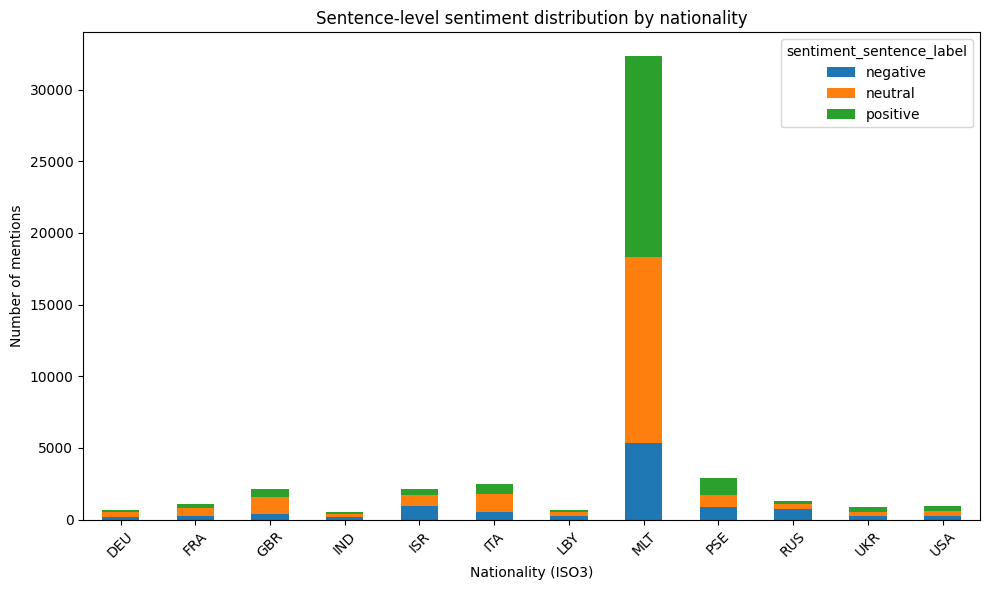

In [ ]:
mentions = pd.read_csv("Data/Articles/Output/Articles_merged_mentions.csv")

top_codes = mentions["code"].value_counts().head(12).index

plot_df = (
    mentions[mentions["code"].isin(top_codes)]
    .groupby(["code", "sentiment_sentence_label"])
    .size()
    .unstack(fill_value=0)
)

plot_df.plot(kind="bar", stacked=True, figsize=(10,6))
plt.title("Sentence-level sentiment distribution by nationality")
plt.xlabel("Nationality (ISO3)")
plt.ylabel("Number of mentions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

2. Negative sentiment rate by nationality

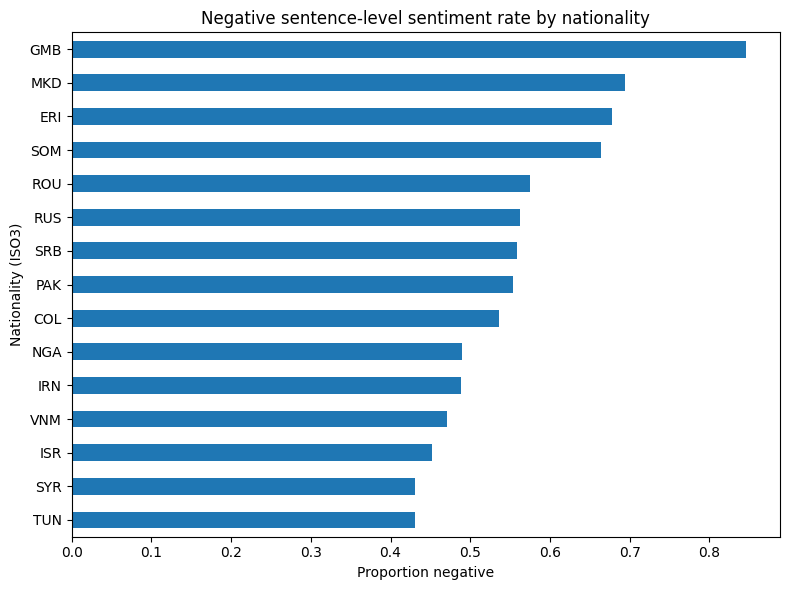

In [ ]:
sent_rate = (
    mentions.groupby("code")["sentiment_sentence_label"]
    .apply(lambda s: (s == "negative").mean())
    .sort_values(ascending=False)
)

sent_rate = sent_rate[mentions["code"].value_counts() >= 30]  # Threshold can be adjusted
sent_rate.head(15).sort_values().plot(kind="barh", figsize=(8,6))
plt.title("Negative sentence-level sentiment rate by nationality")
plt.xlabel("Proportion negative")
plt.ylabel("Nationality (ISO3)")
plt.tight_layout()
plt.show()

3. Average sentence sentiment probabilities by nationality

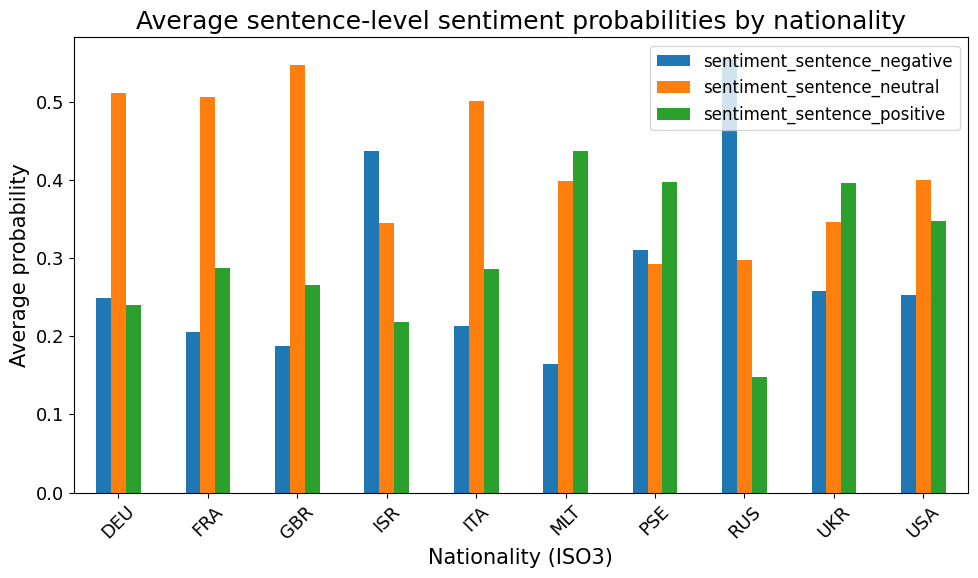

In [59]:
prob_cols = [
    "sentiment_sentence_negative",
    "sentiment_sentence_neutral",
    "sentiment_sentence_positive"
]

top_codes = mentions["code"].value_counts().head(10).index

plot_df = (
    mentions[mentions["code"].isin(top_codes)]
    .groupby("code")[prob_cols]
    .mean()
)

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 18,
    "axes.labelsize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 12,
    "legend.title_fontsize": 13
})

plot_df.plot(kind="bar", figsize=(10,6))
plt.title("Average sentence-level sentiment probabilities by nationality")
plt.xlabel("Nationality (ISO3)")
plt.ylabel("Average probability")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

4. Article-level sentiment distribution for articles mentioning each nationality

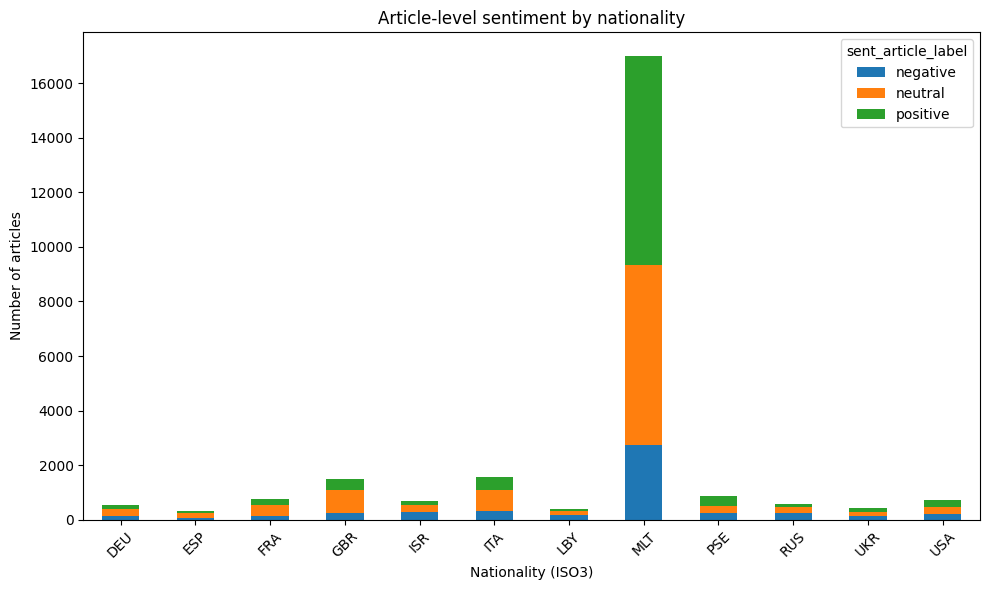

In [ ]:
enriched = pd.read_csv("Data/Articles/Output/Articles_merged_enriched.csv")

tmp = enriched.copy()
tmp["nationalities_iso3"] = tmp["nationalities_iso3"].fillna("[]").apply(ast.literal_eval)
tmp = tmp.explode("nationalities_iso3")
tmp = tmp[tmp["nationalities_iso3"].notna() & (tmp["nationalities_iso3"] != "")]

top_codes = tmp["nationalities_iso3"].value_counts().head(12).index

plot_df = (
    tmp[tmp["nationalities_iso3"].isin(top_codes)]
    .groupby(["nationalities_iso3", "sent_article_label"])
    .size()
    .unstack(fill_value=0)
)

plot_df.plot(kind="bar", stacked=True, figsize=(10,6))
plt.title("Article-level sentiment by nationality")
plt.xlabel("Nationality (ISO3)")
plt.ylabel("Number of articles")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Framing

1. Article-level frame prevalence by nationality

- shows: for each nationality, the proportion of articles mentioning it that contain each frame

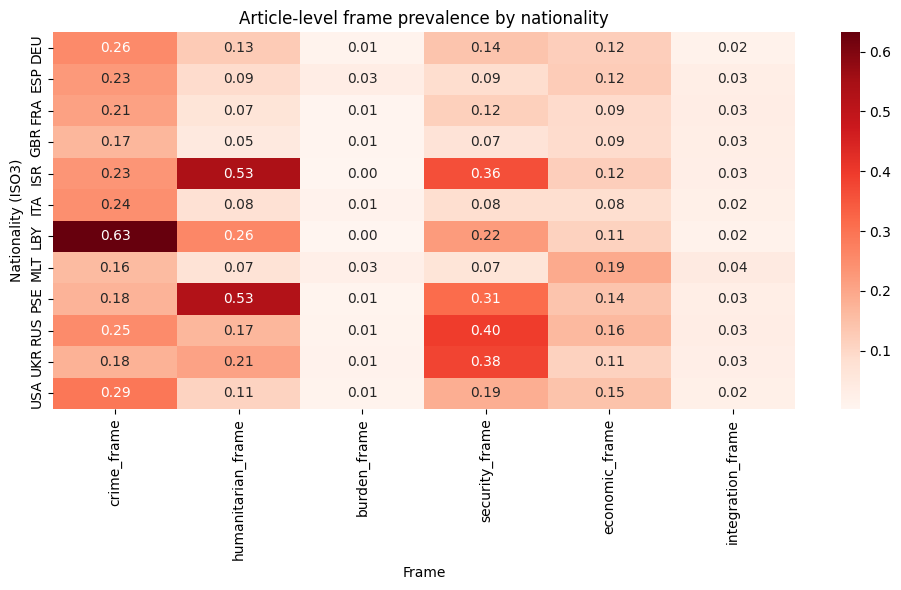

In [ ]:
frame_cols = [
    "crime_frame", "humanitarian_frame", "burden_frame",
    "security_frame", "economic_frame", "integration_frame"
]

tmp = enriched.copy()
tmp["nationalities_iso3"] = tmp["nationalities_iso3"].fillna("[]").apply(ast.literal_eval)
tmp = tmp.explode("nationalities_iso3")
tmp = tmp[tmp["nationalities_iso3"].notna() & (tmp["nationalities_iso3"] != "")]

top_codes = tmp["nationalities_iso3"].value_counts().head(12).index

heatmap_df = (
    tmp[tmp["nationalities_iso3"].isin(top_codes)]
    .groupby("nationalities_iso3")[frame_cols]
    .mean()
)

plt.figure(figsize=(10,6))
sns.heatmap(heatmap_df, annot=True, cmap="Reds", fmt=".2f")
plt.title("Article-level frame prevalence by nationality")
plt.xlabel("Frame")
plt.ylabel("Nationality (ISO3)")
plt.tight_layout()
plt.show()

2. Paragraph-level frame prevalence by nationality
- shows whether nationalities are associated with certain frames in the paragraphs where they appear

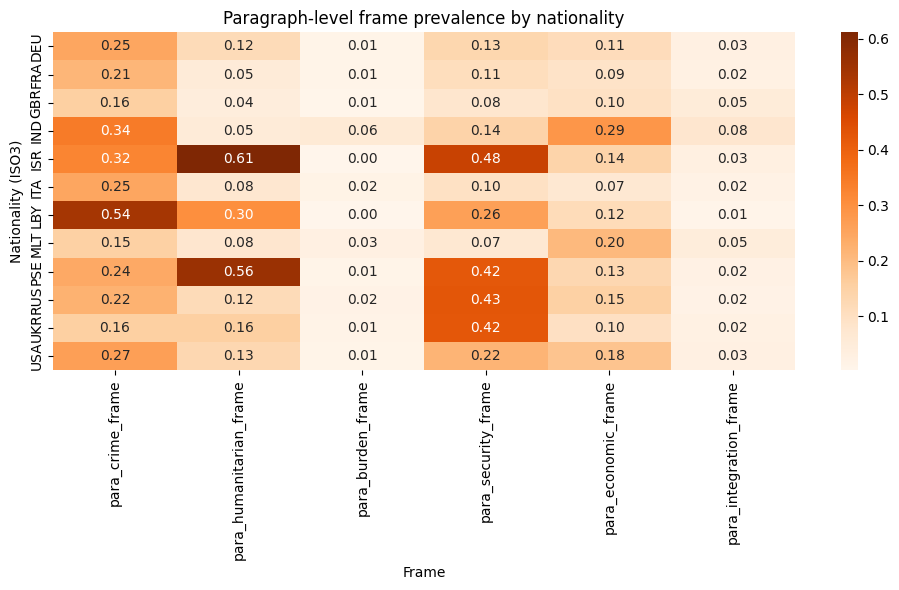

In [37]:
para_frame_cols = [
    "para_crime_frame", "para_humanitarian_frame", "para_burden_frame",
    "para_security_frame", "para_economic_frame", "para_integration_frame"
]

top_codes = mentions["code"].value_counts().head(12).index

heatmap_df = (
    mentions[mentions["code"].isin(top_codes)]
    .groupby("code")[para_frame_cols]
    .mean()
)

plt.figure(figsize=(10,6))
sns.heatmap(heatmap_df, annot=True, cmap="Oranges", fmt=".2f")
plt.title("Paragraph-level frame prevalence by nationality")
plt.xlabel("Frame")
plt.ylabel("Nationality (ISO3)")
plt.tight_layout()
plt.show()

3. Dominant frame by nationality
- What it shows: the single most prevalent article-level frame for each nationality.

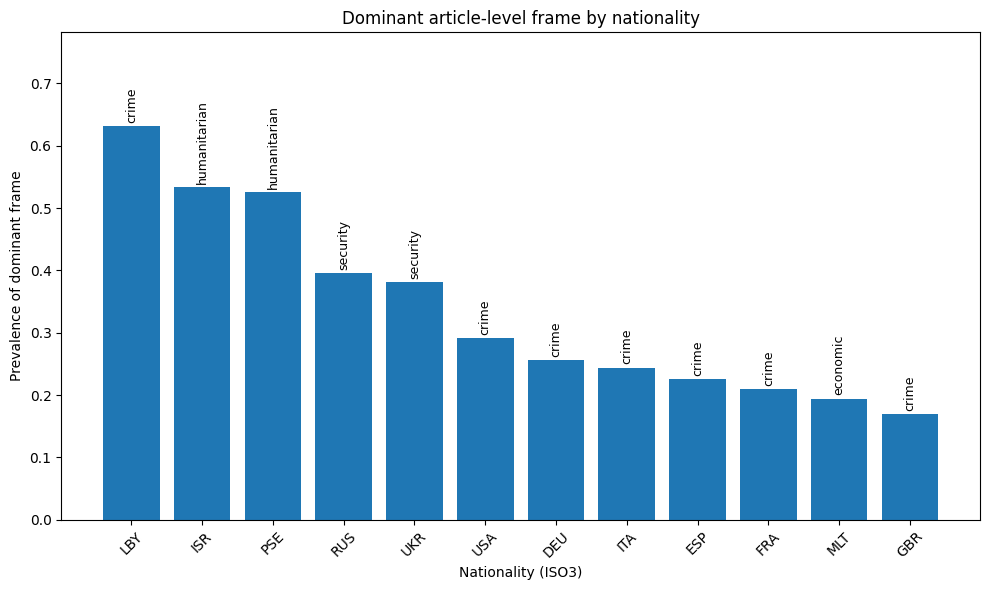

In [ ]:
# Article-level frame columns
frame_cols = [
    "crime_frame",
    "humanitarian_frame",
    "burden_frame",
    "security_frame",
    "economic_frame",
    "integration_frame"
]

tmp = enriched.copy()
tmp["nationalities_iso3"] = tmp["nationalities_iso3"].fillna("[]").apply(ast.literal_eval)
tmp = tmp.explode("nationalities_iso3")
tmp = tmp[tmp["nationalities_iso3"].notna() & (tmp["nationalities_iso3"] != "")]

# Keep only top nationalities
top_codes = tmp["nationalities_iso3"].value_counts().head(12).index
tmp = tmp[tmp["nationalities_iso3"].isin(top_codes)]

# Mean prevalence of each frame by nationality
frame_means = tmp.groupby("nationalities_iso3")[frame_cols].mean()

# Get dominant frame and its prevalence
dominant = pd.DataFrame({
    "dominant_frame": frame_means.idxmax(axis=1),
    "dominant_value": frame_means.max(axis=1)
}).sort_values("dominant_value", ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(dominant.index, dominant["dominant_value"])
for i, (_, row) in enumerate(dominant.iterrows()):
    plt.text(i, row["dominant_value"] + 0.01, row["dominant_frame"].replace("_frame", ""), 
             ha="center", rotation=90, fontsize=9)

plt.title("Dominant article-level frame by nationality")
plt.xlabel("Nationality (ISO3)")
plt.ylabel("Prevalence of dominant frame")
plt.xticks(rotation=45)
plt.ylim(0, min(1.05, dominant["dominant_value"].max() + 0.15))
plt.tight_layout()
plt.show()

4. Frame composition for one nationality at a time
- What it shows: for a selected nationality, how its article mentions distribute across all frames.

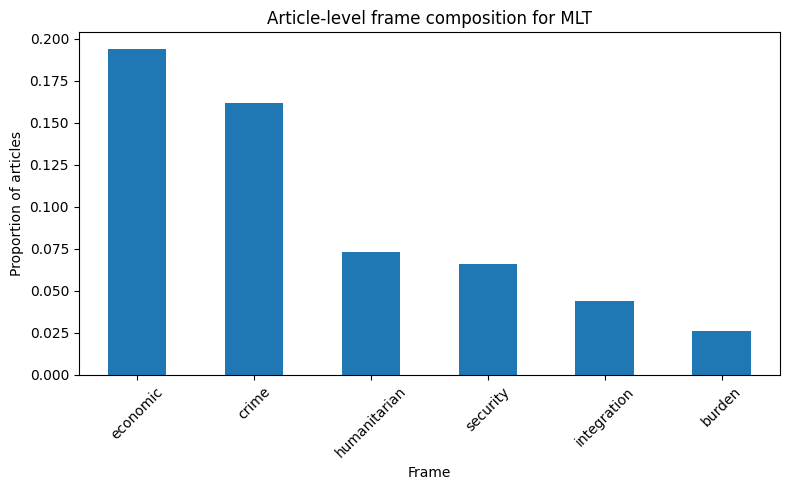

In [ ]:
# Choose nationality here
selected_code = "MLT"

tmp = enriched.copy()
tmp["nationalities_iso3"] = tmp["nationalities_iso3"].fillna("[]").apply(ast.literal_eval)
tmp = tmp.explode("nationalities_iso3")
tmp = tmp[tmp["nationalities_iso3"].notna() & (tmp["nationalities_iso3"] != "")]

# Filter selected nationality
sub = tmp[tmp["nationalities_iso3"] == selected_code]

# Average prevalence of each frame
frame_profile = sub[frame_cols].mean().sort_values(ascending=False)
frame_profile.index = frame_profile.index.str.replace("_frame", "", regex=False)

# Plot
plt.figure(figsize=(8, 5))
frame_profile.plot(kind="bar")
plt.title(f"Article-level frame composition for {selected_code}")
plt.xlabel("Frame")
plt.ylabel("Proportion of articles")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

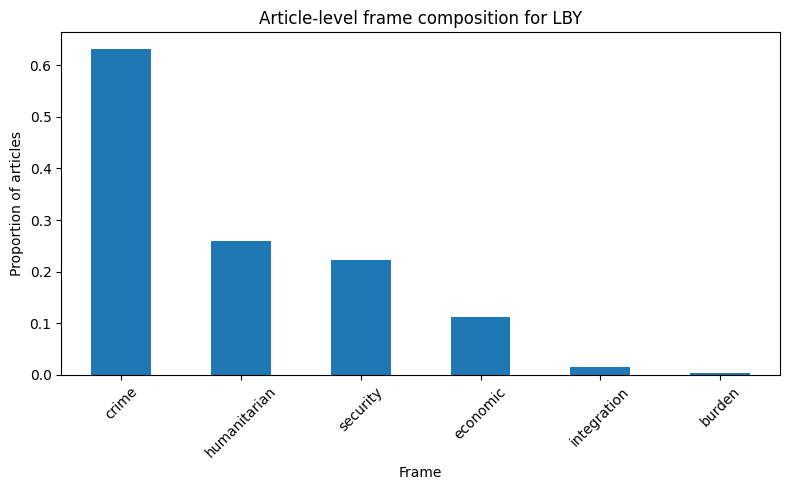

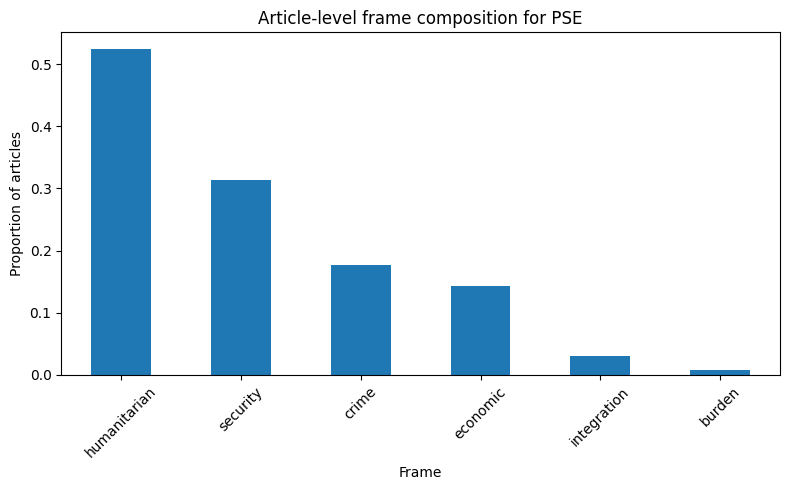

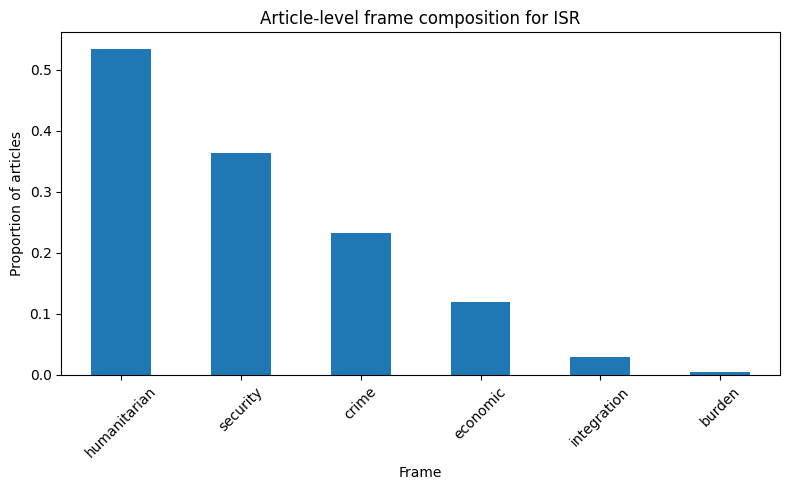

In [48]:
codes_to_plot = ["LBY", "PSE", "ISR"]

for selected_code in codes_to_plot:
    sub = tmp[tmp["nationalities_iso3"] == selected_code]
    frame_profile = sub[frame_cols].mean().sort_values(ascending=False)
    frame_profile.index = frame_profile.index.str.replace("_frame", "", regex=False)

    plt.figure(figsize=(8, 5))
    frame_profile.plot(kind="bar")
    plt.title(f"Article-level frame composition for {selected_code}")
    plt.xlabel("Frame")
    plt.ylabel("Proportion of articles")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

5. Sentence-level framing plot
- shows: sentence-context frame prevalence for nationality mentions.

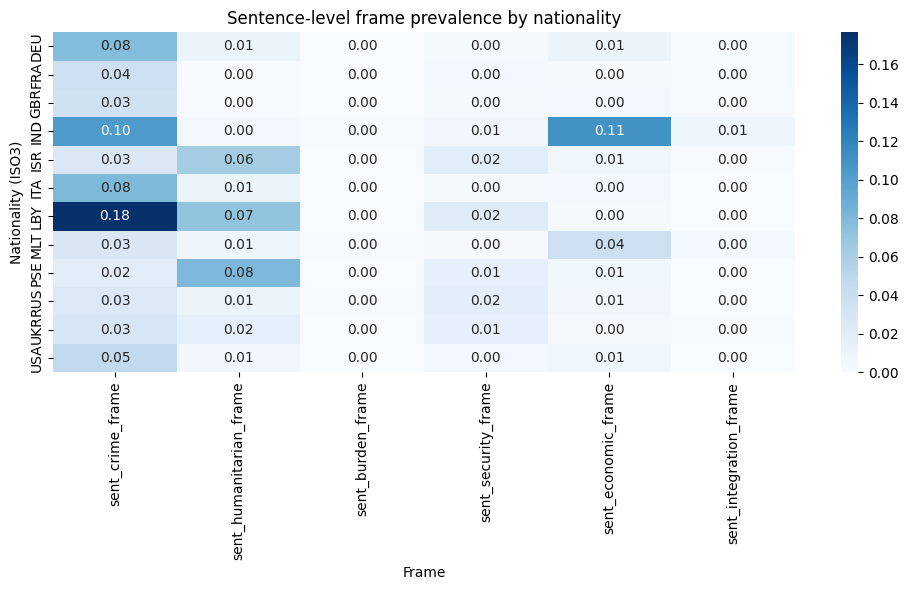

In [38]:
sent_frame_cols = [
    "sent_crime_frame", "sent_humanitarian_frame", "sent_burden_frame",
    "sent_security_frame", "sent_economic_frame", "sent_integration_frame"
]

top_codes = mentions["code"].value_counts().head(12).index

heatmap_df = (
    mentions[mentions["code"].isin(top_codes)]
    .groupby("code")[sent_frame_cols]
    .mean()
)

plt.figure(figsize=(10,6))
sns.heatmap(heatmap_df, annot=True, cmap="Blues", fmt=".2f")
plt.title("Sentence-level frame prevalence by nationality")
plt.xlabel("Frame")
plt.ylabel("Nationality (ISO3)")
plt.tight_layout()
plt.show()

### Sentiment + Framing

1. Negative sentiment within each frame by nationality
- What it shows: for each nationality, whether negative tone is especially strong when coverage is framed as crime, security, burden, etc.

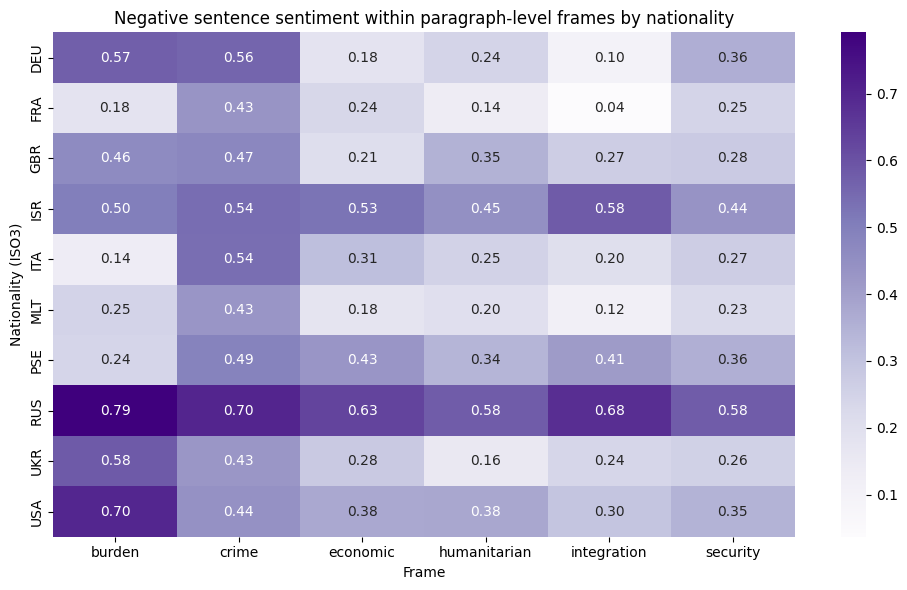

In [39]:
frame_map = {
    "crime": "para_crime_frame",
    "humanitarian": "para_humanitarian_frame",
    "burden": "para_burden_frame",
    "security": "para_security_frame",
    "economic": "para_economic_frame",
    "integration": "para_integration_frame"
}

top_codes = mentions["code"].value_counts().head(10).index
rows = []

for code in top_codes:
    sub = mentions[mentions["code"] == code]
    for frame_name, col in frame_map.items():
        frame_sub = sub[sub[col] == 1]
        if len(frame_sub) > 0:
            neg_rate = (frame_sub["sentiment_sentence_label"] == "negative").mean()
            rows.append([code, frame_name, neg_rate])

plot_df = pd.DataFrame(rows, columns=["code", "frame", "negative_rate"])
heatmap_df = plot_df.pivot(index="code", columns="frame", values="negative_rate")

plt.figure(figsize=(10,6))
sns.heatmap(heatmap_df, annot=True, cmap="Purples", fmt=".2f")
plt.title("Negative sentence sentiment within paragraph-level frames by nationality")
plt.xlabel("Frame")
plt.ylabel("Nationality (ISO3)")
plt.tight_layout()
plt.show()

2. Sentiment distribution inside each frame
- What it shows: whether crime/security/burden frames are mostly negative, while humanitarian/integration may be more neutral or mixed.

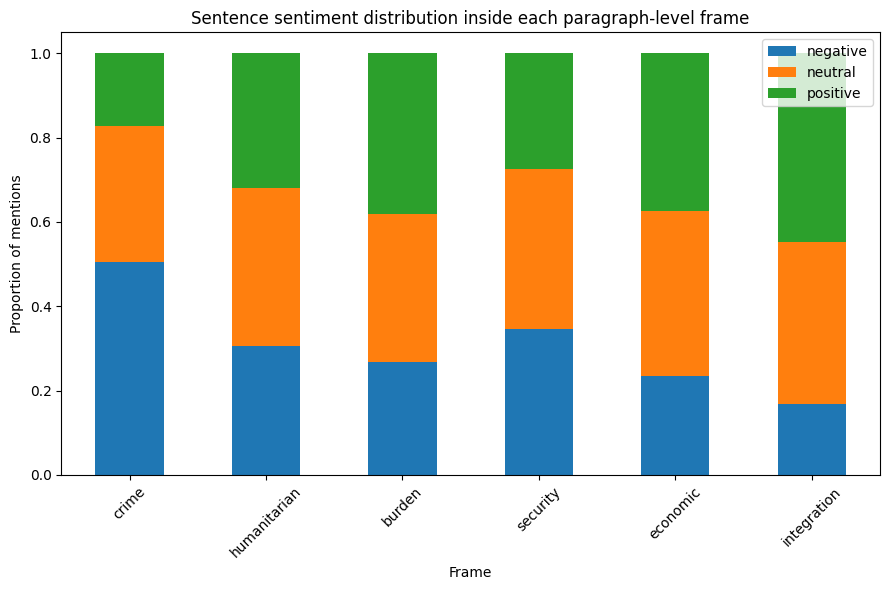

In [49]:
rows = []

for frame_name, frame_col in frame_map.items():
    sub = mentions[mentions[frame_col] == 1]
    if len(sub) == 0:
        continue

    dist = sub["sentiment_sentence_label"].value_counts(normalize=True)
    rows.append({
        "frame": frame_name,
        "negative": dist.get("negative", 0),
        "neutral": dist.get("neutral", 0),
        "positive": dist.get("positive", 0)
    })

plot_df = pd.DataFrame(rows).set_index("frame")

plot_df.plot(kind="bar", stacked=True, figsize=(9, 6))
plt.title("Sentence sentiment distribution inside each paragraph-level frame")
plt.xlabel("Frame")
plt.ylabel("Proportion of mentions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

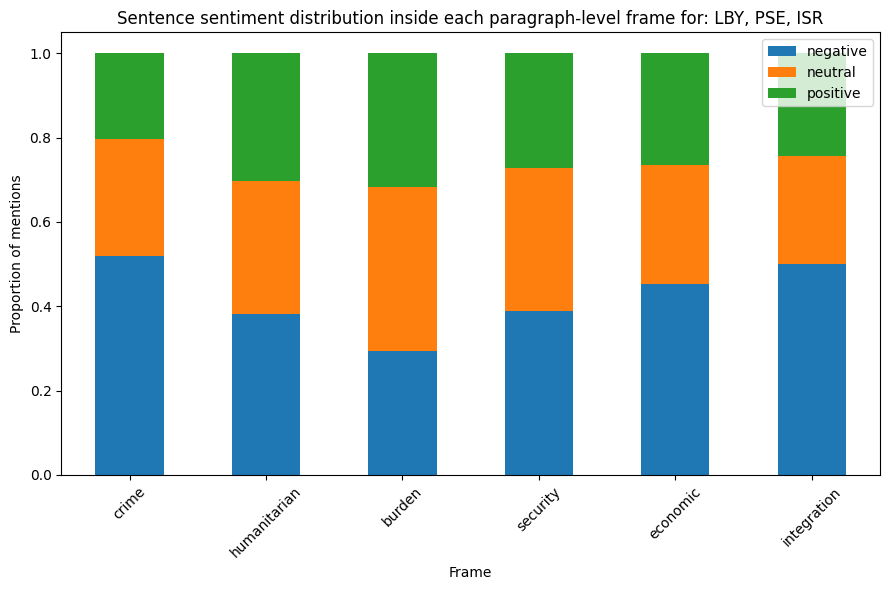

In [51]:
selected_codes = ["LBY", "PSE", "ISR"]
mentions_copy = mentions[mentions["code"].isin(selected_codes)].copy()


rows = []

for frame_name, frame_col in frame_map.items():
    sub = mentions_copy[mentions_copy[frame_col] == 1]
    if len(sub) == 0:
        continue

    dist = sub["sentiment_sentence_label"].value_counts(normalize=True)
    rows.append({
        "frame": frame_name,
        "negative": dist.get("negative", 0),
        "neutral": dist.get("neutral", 0),
        "positive": dist.get("positive", 0)
    })

plot_df = pd.DataFrame(rows).set_index("frame")

plot_df.plot(kind="bar", stacked=True, figsize=(9, 6))
plt.title(f"Sentence sentiment distribution inside each paragraph-level frame for: {', '.join(selected_codes)}")
plt.xlabel("Frame")
plt.ylabel("Proportion of mentions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

3. Bubble plot: frame prevalence vs negative sentiment by nationality
- What it shows: whether nationalities more associated with a frame also receive more negative sentiment.

    Example:

- x = prevalence of para_crime_frame
- y = negative sentiment rate
- bubble size = number of mentions/articles
- each point = nationality

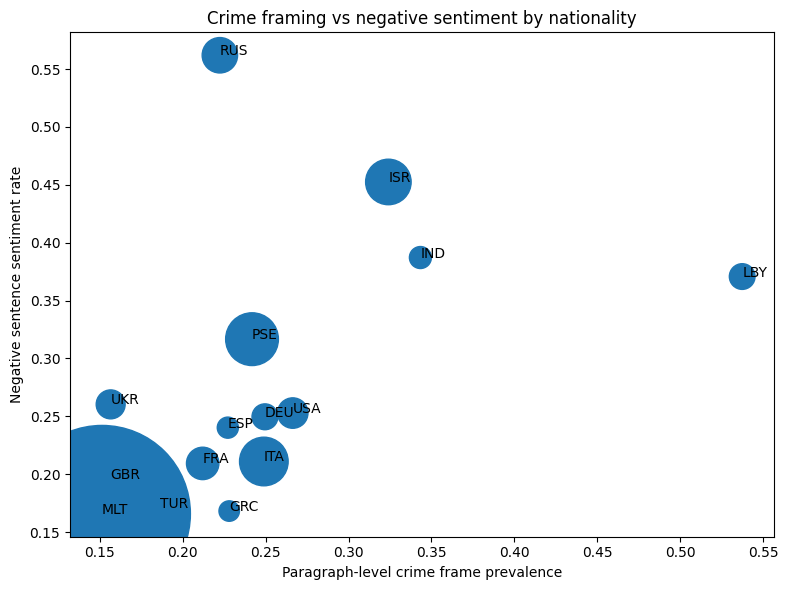

In [40]:
top_codes = mentions["code"].value_counts().head(15).index
sub = mentions[mentions["code"].isin(top_codes)]

plot_df = sub.groupby("code").agg(
    crime_prev=("para_crime_frame", "mean"),
    neg_rate=("sentiment_sentence_label", lambda s: (s == "negative").mean()),
    n=("code", "size")
).reset_index()

plt.figure(figsize=(8,6))
plt.scatter(plot_df["crime_prev"], plot_df["neg_rate"], s=plot_df["n"]*0.5)
for _, row in plot_df.iterrows():
    plt.text(row["crime_prev"], row["neg_rate"], row["code"])

plt.title("Crime framing vs negative sentiment by nationality")
plt.xlabel("Paragraph-level crime frame prevalence")
plt.ylabel("Negative sentence sentiment rate")
plt.tight_layout()
plt.show()

4. Faceted heatmaps: one heatmap per sentiment class
 - What it shows: for each nationality, which frames co-occur with negative, neutral, or positive sentiment.

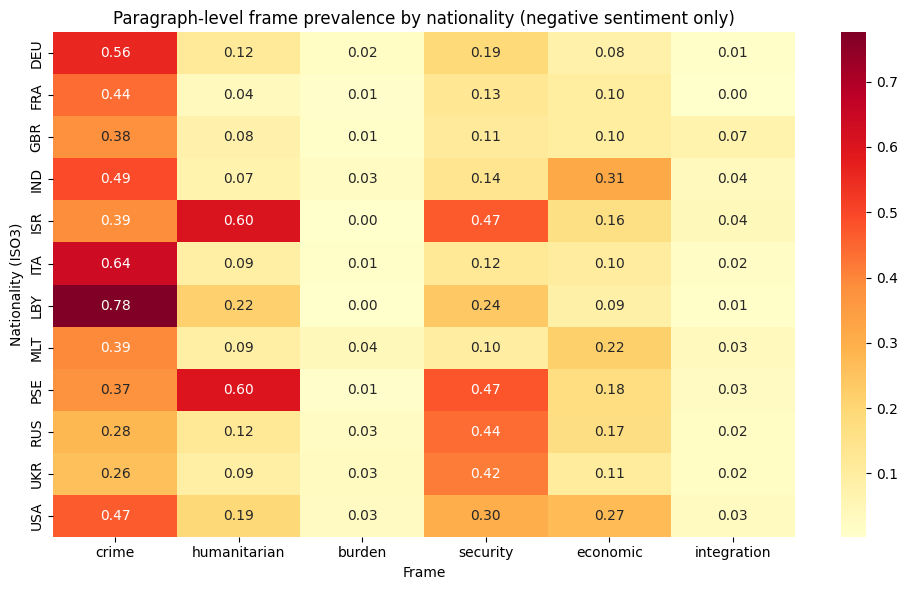

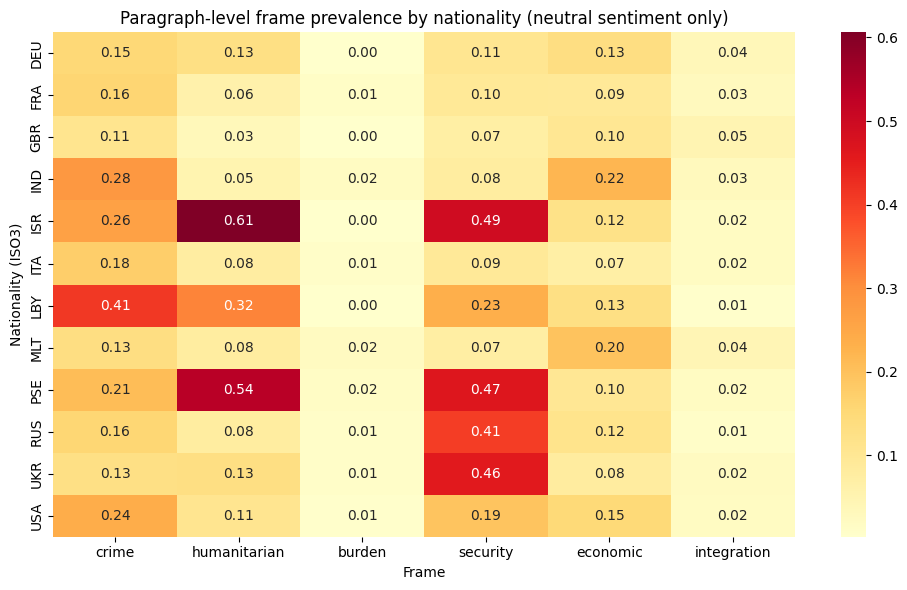

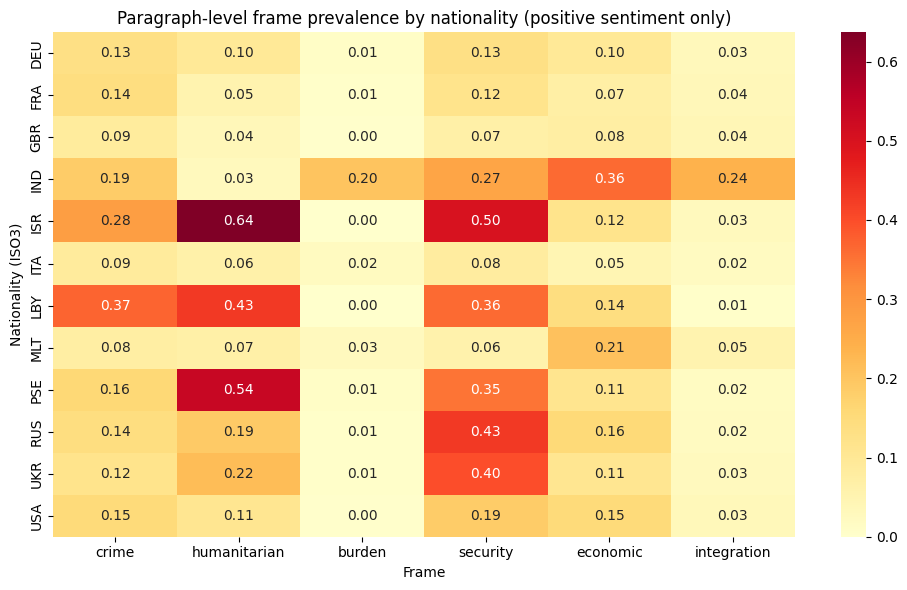

In [53]:

frame_cols = [
    "para_crime_frame",
    "para_humanitarian_frame",
    "para_burden_frame",
    "para_security_frame",
    "para_economic_frame",
    "para_integration_frame"
]

# Keep only top nationalities (optional)
top_codes = mentions["code"].value_counts().head(12).index
mentions_sub = mentions[mentions["code"].isin(top_codes)].copy()

sentiment_classes = ["negative", "neutral", "positive"]

for sent_label in sentiment_classes:
    sub = mentions_sub[mentions_sub["sentiment_sentence_label"] == sent_label]

    heatmap_df = sub.groupby("code")[frame_cols].mean()
    heatmap_df.columns = [c.replace("para_", "").replace("_frame", "") for c in heatmap_df.columns]

    plt.figure(figsize=(10, 6))
    sns.heatmap(heatmap_df, annot=True, cmap="YlOrRd", fmt=".2f")
    plt.title(f"Paragraph-level frame prevalence by nationality ({sent_label} sentiment only)")
    plt.xlabel("Frame")
    plt.ylabel("Nationality (ISO3)")
    plt.tight_layout()
    plt.show()

Nationality-specific version of the frame-conditioned sentiment score plot

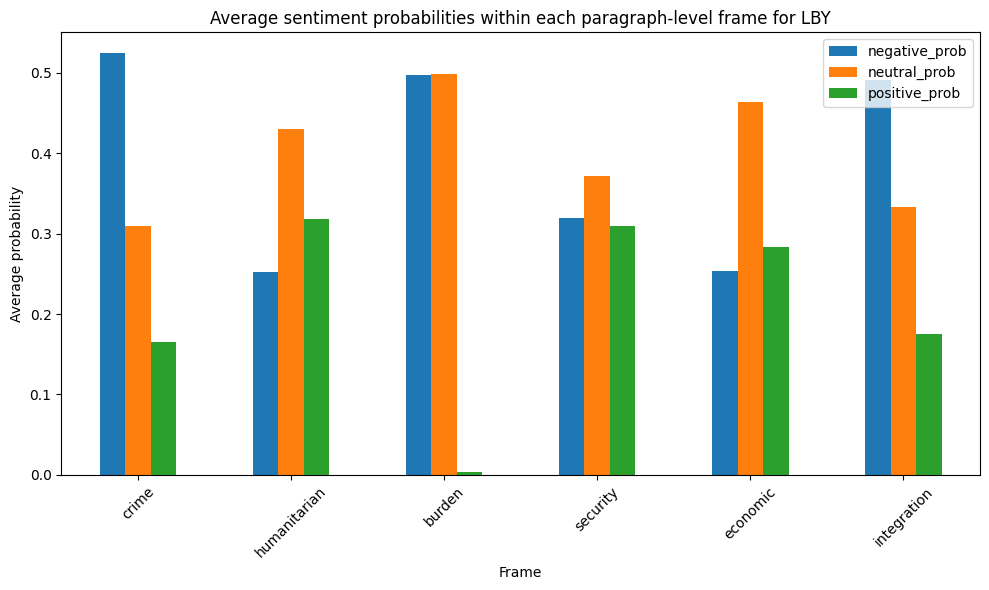

In [56]:
selected_code = "LBY"   

frame_map = {
    "crime": "para_crime_frame",
    "humanitarian": "para_humanitarian_frame",
    "burden": "para_burden_frame",
    "security": "para_security_frame",
    "economic": "para_economic_frame",
    "integration": "para_integration_frame"
}

prob_cols = [
    "sentiment_sentence_negative",
    "sentiment_sentence_neutral",
    "sentiment_sentence_positive"
]

sub_all = mentions[mentions["code"] == selected_code].copy()

rows = []

for frame_name, frame_col in frame_map.items():
    sub = sub_all[sub_all[frame_col] == 1]
    if len(sub) == 0:
        continue

    means = sub[prob_cols].mean()

    rows.append({
        "frame": frame_name,
        "negative_prob": means["sentiment_sentence_negative"],
        "neutral_prob": means["sentiment_sentence_neutral"],
        "positive_prob": means["sentiment_sentence_positive"]
    })

plot_df = pd.DataFrame(rows).set_index("frame")

plot_df.plot(kind="bar", figsize=(10, 6))
plt.title(f"Average sentiment probabilities within each paragraph-level frame for {selected_code}")
plt.xlabel("Frame")
plt.ylabel("Average probability")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

5. Frame-conditioned sentiment score plot
- What it shows: average negative/neutral/positive probability when a nationality appears in a given paragraph-level frame.

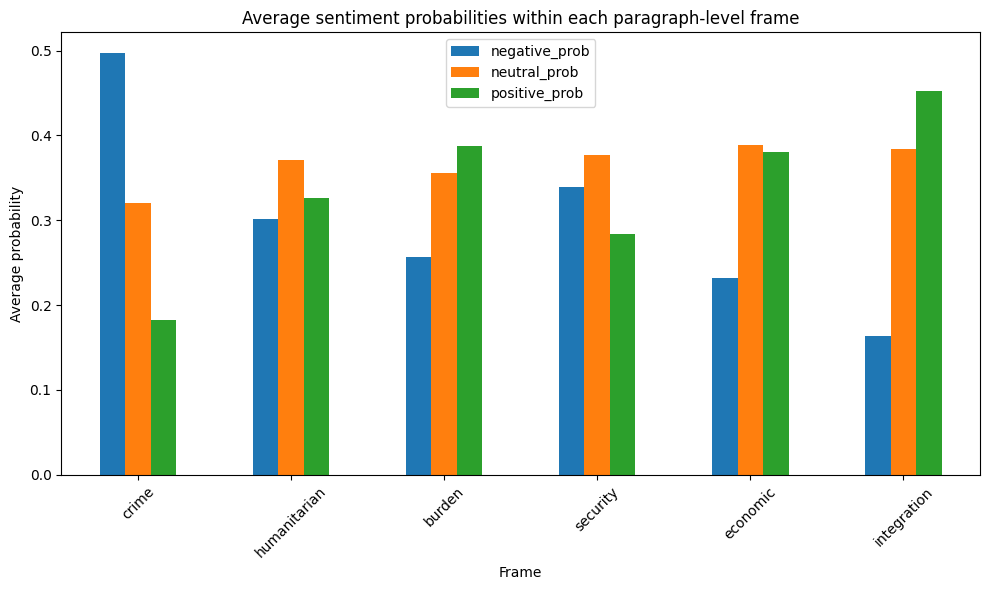

In [54]:
frame_map = {
    "crime": "para_crime_frame",
    "humanitarian": "para_humanitarian_frame",
    "burden": "para_burden_frame",
    "security": "para_security_frame",
    "economic": "para_economic_frame",
    "integration": "para_integration_frame"
}

prob_cols = [
    "sentiment_sentence_negative",
    "sentiment_sentence_neutral",
    "sentiment_sentence_positive"
]

rows = []

for frame_name, frame_col in frame_map.items():
    sub = mentions[mentions[frame_col] == 1]
    if len(sub) == 0:
        continue

    means = sub[prob_cols].mean()

    rows.append({
        "frame": frame_name,
        "negative_prob": means["sentiment_sentence_negative"],
        "neutral_prob": means["sentiment_sentence_neutral"],
        "positive_prob": means["sentiment_sentence_positive"]
    })

plot_df = pd.DataFrame(rows).set_index("frame")

plot_df.plot(kind="bar", figsize=(10, 6))
plt.title("Average sentiment probabilities within each paragraph-level frame")
plt.xlabel("Frame")
plt.ylabel("Average probability")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()